# 🇺🇸 United States Labour Market Analysis (2017–2026)
### A Data Analyst Portfolio Project

---

**Author:** Mukuka  
**Data Sources:** U.S. Bureau of Labor Statistics (BLS) · Federal Reserve Bank of St. Louis (FRED)  
**Tools:** Python · Pandas · Matplotlib · Seaborn · Plotly · SQLite · pandas-datareader  
**Period Covered:** January 2017 – May 2026  

---

## 📋 Project Overview

This notebook investigates the U.S. labour market through **official government data**, building a complete data-driven narrative — from raw API calls through cleaning, visualisation, and SQL analysis.

**Central question answered by this project:**
> *What is driving the recent slowdown in U.S. job growth, and how does it connect to inflation and Federal Reserve policy?*

---

## 🗂️ Table of Contents

| Section | Topic | Key Question |
|---|---|---|
| **1** | Setup & Libraries | What tools do we need? |
| **2** | Data Collection | Where does the data come from? |
| **2.5** | Economic Indicators | How do inflation and interest rates connect to hiring? |
| **3** | Data Quality | Is the data clean and complete? |
| **4** | Unemployment Rate | How has joblessness changed from 2017 to 2026? |
| **5** | Jobs Added | When did the economy create or destroy jobs? |
| **6** | Top Occupations | Which jobs employ the most Americans, and what do they pay? |
| **7** | Industry Trends | Which sectors grew or shrank post-COVID? |
| **8** | Causes of Unemployment | What economic events drive people out of work? |
| **9** | SQL Analysis | What do targeted queries reveal about the data? |
| **10** | Key Insights | What is the full story the data tells? |

---

> 💡 **How to read this notebook:** Every code cell includes `# comments` explaining each line. Read the markdown above each cell for context before stepping through the code.

---
## 🔧 Section 1: Setup — Importing Libraries

| Library | Purpose |
|---|---|
| `pandas` | Load, clean, and reshape tabular data |
| `matplotlib` | Core Python charting library |
| `seaborn` | Higher-level charts built on matplotlib |
| `plotly` | Interactive, browser-renderable dashboards |
| `requests` | Make HTTP calls to the BLS API |
| `json` | Parse JSON responses from APIs |
| `sqlite3` | Lightweight in-process SQL database |
| `pandas_datareader` | Fetch Federal Reserve (FRED) data directly into pandas |
| `warnings` | Suppress non-critical warning messages |

In [378]:
# ── Import all libraries we'll need throughout this notebook ──

import pandas as pd          # Data manipulation
import matplotlib.pyplot as plt  # Base plotting
import matplotlib.ticker as mtick  # For formatting axis labels (e.g., percentages)
import seaborn as sns        # Statistical visualizations
import requests              # HTTP requests to APIs
import json                  # Parse JSON responses
import sqlite3               # SQL database
import warnings              # Suppress harmless warnings
!pip install pandas-datareader
# Suppress FutureWarnings so the output stays clean
warnings.filterwarnings('ignore')

# ── Set a consistent visual style for all charts ──
# 'whitegrid' adds a white background with light grid lines — clean and professional
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)

# Tell matplotlib to display charts directly inside this notebook
%matplotlib inline

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


---
## 📥 Section 2: Data Collection — BLS & FRED APIs

All employment data is fetched from the **Bureau of Labor Statistics (BLS)** public API. Monetary policy data (Federal Funds Rate) is fetched from the **Federal Reserve Bank of St. Louis (FRED)**.

### BLS Series Used

| Series ID | Indicator |
|---|---|
| `LNS14000000` | U.S. Unemployment Rate (%) |
| `CES0000000001` | Total Nonfarm Payrolls — monthly jobs added/lost |
| `CES2000000001` | Construction employment |
| `CES3000000001` | Manufacturing employment |
| `CES4000000001` | Trade, Transportation & Utilities |
| `CES5000000001` | Information sector |
| `CES6000000001` | Professional & Business Services |
| `CES6500000001` | Education & Health Services |
| `CES7000000001` | Leisure & Hospitality |
| `CES9000000001` | Government |
| `CUSR0000SA0` | CPI — Consumer Price Index (inflation) |
| `CES0500000003` | Average Hourly Earnings — private sector |

### FRED Series Used

| Series ID | Indicator |
|---|---|
| `FEDFUNDS` | Effective Federal Funds Rate (%) |

### API Limits
- **Without a key:** 25 requests/day, up to 10 years per call
- **With a free BLS key:** 500 requests/day, up to 20 years — register at `data.bls.gov/registrationEngine`

In [379]:
# ─────────────────────────────────────────────────────────────
# OPTIONAL: If you registered for a BLS API key, paste it here.
# Leave as None — the code handles both cases.
# ─────────────────────────────────────────────────────────────
BLS_API_KEY = None   # e.g., BLS_API_KEY = 'your_key_here'


def fetch_bls_series(series_ids, start_year, end_year):
    import requests
    url = 'https://api.bls.gov/publicAPI/v2/timeseries/data/'
    payload = {'seriesid': series_ids, 'startyear': start_year, 'endyear': end_year}
    if BLS_API_KEY:
        payload['registrationkey'] = BLS_API_KEY
    # timeout=15 means give up if no response in 15 seconds
    response = requests.post(url, json=payload, timeout=15)
    if response.status_code != 200:
        raise ConnectionError(f'BLS API call failed: {response.status_code}')
    return response.json()


def bls_response_to_dataframe(response, series_id):
    series_list = response['Results']['series']
    target = next(s for s in series_list if s['seriesID'] == series_id)
    rows = []
    for item in target['data']:
        year, period, value = item['year'], item['period'], item['value']
        if period == 'M13':
            continue
        # BLS returns '-' for months not yet released — skip them
        if value == '-' or value is None:
            continue
        try:
            float_val = float(value)
        except (ValueError, TypeError):
            continue
        month = int(period.replace('M', ''))
        date  = pd.Timestamp(year=int(year), month=month, day=1)
        rows.append({'date': date, 'value': float_val})
    # If no rows came back (e.g. a bad series ID), still return a DataFrame
    # with the expected columns instead of crashing on an empty one
    if not rows:
        return pd.DataFrame(columns=['date', 'value'])
    return pd.DataFrame(rows).sort_values('date').reset_index(drop=True)


print('Helper functions ready: fetch_bls_series() and bls_response_to_dataframe()')

Helper functions ready: fetch_bls_series() and bls_response_to_dataframe()


### 2.1 Fetch Unemployment Rate Data

The **unemployment rate** tells us what percentage of the labour force is jobless but actively seeking work. The BLS tracks this monthly going back to 1948. We'll fetch data from 2017 onwards to capture the most relevant recent economic cycle:

| Event | Year(s) | Notes |
|---|---|---|
| Pre-pandemic boom | 2018–2019 | 50-year unemployment low (~3.5%) |
| COVID-19 pandemic spike | 2020 | Peak of ~14.7% in April 2020 |
| Historic rapid recovery | 2021–2022 | Fastest recovery on record |
| Fed rate hikes (inflation fight) | 2022–2023 | 11 consecutive rate increases |
| Labour market normalization | 2024–2026 | Gradual cooling toward full employment |

> 💡 **Why 2017–2026?** The free BLS API returns up to 10 years of data per call. Anchoring to 2017 captures COVID, the recovery, and current conditions — far more relevant for understanding today's job market than data from 2000–2009.

In [380]:
# ── Fetch the monthly U.S. unemployment rate from 2017 to 2026 ──

print('Fetching unemployment rate data from BLS...')

# 'LNS14000000' is the BLS Series ID for the seasonally adjusted
# civilian unemployment rate
unemp_response = fetch_bls_series(
    series_ids=['LNS14000000'],
    start_year='2017',
    end_year='2026'
)

# Convert the raw API response into a clean DataFrame
df_unemployment = bls_response_to_dataframe(unemp_response, 'LNS14000000')

# Rename the 'value' column to something descriptive
df_unemployment = df_unemployment.rename(columns={'value': 'unemployment_rate'})

# Preview the first 5 rows to confirm everything looks right
print(f'\n✅ Downloaded {len(df_unemployment)} monthly observations')
print(f'   Date range: {df_unemployment["date"].min().strftime("%b %Y")} → {df_unemployment["date"].max().strftime("%b %Y")}')
print('\nFirst 5 rows:')
df_unemployment.head()

Fetching unemployment rate data from BLS...

✅ Downloaded 112 monthly observations
   Date range: Jan 2017 → May 2026

First 5 rows:


,date,unemployment_rate
0,2017-01-01,4.7
1,2017-02-01,4.6
2,2017-03-01,4.4
3,2017-04-01,4.4
4,2017-05-01,4.4


### 2.2 Fetch Nonfarm Payrolls Data

**Nonfarm payrolls** is the most watched economic indicator in the world. Released on the first Friday of every month (the "jobs report"), it measures how many jobs the U.S. economy added or lost in the previous month.

- A **positive number** = jobs were created (economy expanding)
- A **negative number** = jobs were lost (economy contracting)

In [381]:
# ── Fetch total nonfarm payrolls (total employed, in thousands) ──

print('Fetching nonfarm payrolls data from BLS...')

payroll_response = fetch_bls_series(
    series_ids=['CES0000000001'],  # Total nonfarm employment
    start_year='2017',
    end_year='2026'
)

df_payrolls = bls_response_to_dataframe(payroll_response, 'CES0000000001')

# Rename value to something meaningful
# BLS reports this in thousands (so 150000 = 150 million workers)
df_payrolls = df_payrolls.rename(columns={'value': 'total_employed_thousands'})

# ── Calculate month-over-month job change ──
# .diff() subtracts each row from the previous row
# This gives us "how many jobs were added this month compared to last month"
df_payrolls['jobs_added_thousands'] = df_payrolls['total_employed_thousands'].diff()

# The first row will be NaN (no prior month to subtract from) — drop it
df_payrolls = df_payrolls.dropna().reset_index(drop=True)

print(f'\n✅ Downloaded {len(df_payrolls)} monthly observations')
print(f'   Date range: {df_payrolls["date"].min().strftime("%b %Y")} → {df_payrolls["date"].max().strftime("%b %Y")}')
print(f'   Largest single-month gain:  {df_payrolls["jobs_added_thousands"].max():,.0f}K jobs')
print(f'   Largest single-month loss: {df_payrolls["jobs_added_thousands"].min():,.0f}K jobs')
print('\nFirst 5 rows:')
df_payrolls.head()

Fetching nonfarm payrolls data from BLS...

✅ Downloaded 112 monthly observations
   Date range: Feb 2017 → May 2026
   Largest single-month gain:  4,631K jobs
   Largest single-month loss: -20,469K jobs

First 5 rows:


,date,total_employed_thousands,jobs_added_thousands
0,2017-02-01,145846.0,218.0
1,2017-03-01,145970.0,124.0
2,2017-04-01,146175.0,205.0
3,2017-05-01,146380.0,205.0
4,2017-06-01,146583.0,203.0


### 2.3 Fetch Industry Employment Data

Now we'll pull employment numbers for **10 major industry sectors**. This will let us compare which industries are growing, which are stable, and which are declining over time.

> ⚠️ **Note:** The free BLS API allows only 25 queries per day. We'll bundle all industry series into a single request — this is much more efficient.

In [382]:
# ── Define the BLS Series IDs and human-readable names for each industry ──

# This is a Python dictionary: keys are Series IDs, values are industry names
INDUSTRY_SERIES = {
    'CES2000000001': 'Construction',
    'CES3000000001': 'Manufacturing',
    'CES4000000001': 'Trade, Transport & Utilities',
    'CES5000000001': 'Information',
    'CES6000000001': 'Professional & Business Services',
    'CES6500000001': 'Education & Health Services',
    'CES7000000001': 'Leisure & Hospitality',
    'CES9000000001': 'Government',
    'CES5500000001': 'Financial Activities',
    'CES1000000001': 'Mining & Logging'
}

print('Fetching industry employment data from BLS...')
print('(Requesting all industries in one API call to stay within rate limits)\n')

# Fetch all 10 series in a single API call
# list(INDUSTRY_SERIES.keys()) extracts just the series ID codes
industry_response = fetch_bls_series(
    series_ids=list(INDUSTRY_SERIES.keys()),
    start_year='2017',
    end_year='2026'
)

# ── Build a combined DataFrame with all industries ──
industry_frames = []  # We'll collect individual DataFrames here, then merge them

for series_id, industry_name in INDUSTRY_SERIES.items():
    # Convert the API response for this specific series to a DataFrame
    df_temp = bls_response_to_dataframe(industry_response, series_id)

    # Add a column so we know which industry each row belongs to
    df_temp['industry'] = industry_name

    # Rename 'value' to something descriptive
    df_temp = df_temp.rename(columns={'value': 'employed_thousands'})

    industry_frames.append(df_temp)
    print(f'  ✅ {industry_name}: {len(df_temp)} months')

# Stack all individual DataFrames into one big DataFrame
# ignore_index=True resets the row numbers from 0
df_industry = pd.concat(industry_frames, ignore_index=True)

print(f'\n✅ Combined industry DataFrame: {df_industry.shape[0]} rows × {df_industry.shape[1]} columns')
df_industry.head()

Fetching industry employment data from BLS...
(Requesting all industries in one API call to stay within rate limits)

  ✅ Construction: 113 months
  ✅ Manufacturing: 113 months
  ✅ Trade, Transport & Utilities: 113 months
  ✅ Information: 113 months
  ✅ Professional & Business Services: 113 months
  ✅ Education & Health Services: 113 months
  ✅ Leisure & Hospitality: 113 months
  ✅ Government: 113 months
  ✅ Financial Activities: 113 months
  ✅ Mining & Logging: 113 months

✅ Combined industry DataFrame: 1130 rows × 3 columns


,date,employed_thousands,industry
0,2017-01-01,6840.0,Construction
1,2017-02-01,6881.0,Construction
2,2017-03-01,6902.0,Construction
3,2017-04-01,6916.0,Construction
4,2017-05-01,6931.0,Construction


### 2.4 Top Occupations Data (BLS Occupational Employment Statistics)

The **OES (Occupational Employment and Wage Statistics)** survey measures employment and wages for over 800 specific job titles. The most recent annual release is **May 2024**.

We'll use the **top 20 occupations by total employment** — the jobs with the most workers in the United States.

> 📌 **Key change from prior years:** Home Health & Personal Care Aides overtook Retail Salespersons to become the **#1 largest occupation** in May 2024, reflecting the aging U.S. population driving demand for care workers.

In [383]:
# ── Top 20 U.S. Occupations by Employment (BLS OES, May 2024) ──
# Source: https://www.bls.gov/oes/2024/may/oes_nat.htm
#
# We embed this as a Python dictionary because the OES data is published as
# annual Excel files rather than a real-time API.
# Employment figures are in thousands (e.g., 4049.0 = ~4 million workers)

top_occupations_data = {
    'Occupation': [
        'Home Health & Personal Care Aides',
        'Fast Food & Counter Workers',
        'Retail Salespersons',
        'General & Operations Managers',
        'Cashiers',
        'Registered Nurses',
        'Stockers & Order Fillers',
        'Customer Service Representatives',
        'Laborers & Freight Movers',
        'Office Clerks (General)',
        'Janitors & Cleaners',
        'Waiters & Waitresses',
        'Heavy & Tractor-Trailer Truck Drivers',
        'Software Developers & Engineers',
        'Light Truck Drivers',
        'Accountants & Auditors',
        'Elementary School Teachers',
        'Construction Laborers',
        'Maids & Housekeeping Cleaners',
        'Medical Assistants'
    ],
    # Total workers employed in each occupation (in thousands) — BLS OES May 2024
    'Employment_Thousands': [
        4049.0, 3838.7, 3767.7, 3307.0, 3295.4,
        3209.3, 3218.8, 2852.0, 2791.0, 2572.1,
        2380.9, 2122.6, 2013.5, 1841.3, 1539.0,
        1393.2, 1382.1, 1307.4,  888.1,  884.0
    ],
    # Median annual wages in US dollars — BLS OES May 2024
    'Median_Annual_Wage': [
        35290,  31090,  33210, 107360, 30710,
        93600,  38130,  40990,  40470,  38480,
        36990,  33870,  54320, 132270,  44220,
        82720,  63680,  44840,  34590,  42000
    ],
    # Broad category each occupation belongs to
    'Category': [
        'Healthcare', 'Food Service', 'Retail', 'Management', 'Retail',
        'Healthcare', 'Transportation/Warehousing', 'Business/Admin', 'Transportation/Warehousing', 'Business/Admin',
        'Maintenance', 'Food Service', 'Transportation/Warehousing', 'Technology', 'Transportation/Warehousing',
        'Business/Admin', 'Education', 'Construction', 'Maintenance', 'Healthcare'
    ]
}

# Convert the dictionary to a pandas DataFrame
df_occupations = pd.DataFrame(top_occupations_data)

# Sort from most to least employed so our charts read naturally
df_occupations = df_occupations.sort_values('Employment_Thousands', ascending=False).reset_index(drop=True)

print(f'✅ Top occupations table created: {df_occupations.shape[0]} occupations')
print(f'   Total workers represented: {df_occupations["Employment_Thousands"].sum():,.0f} thousand')
print()
df_occupations

✅ Top occupations table created: 20 occupations
   Total workers represented: 48,653 thousand



,Occupation,Employment_Thousands,Median_Annual_Wage,Category
0,Home Health & Personal Care Aides,4049.0,35290,Healthcare
1,Fast Food & Counter Workers,3838.7,31090,Food Service
2,Retail Salespersons,3767.7,33210,Retail
3,General & Operations Managers,3307.0,107360,Management
4,Cashiers,3295.4,30710,Retail
5,Stockers & Order Fillers,3218.8,38130,Transportation/Warehousing
6,Registered Nurses,3209.3,93600,Healthcare
7,Customer Service Representatives,2852.0,40990,Business/Admin
8,Laborers & Freight Movers,2791.0,40470,Transportation/Warehousing
9,Office Clerks (General),2572.1,38480,Business/Admin


---
## 📈 Section 2.5: Supporting Economic Indicators

To diagnose **why** job growth slowed in 2025–2026, we need three additional series that reveal the full causal chain:

| Indicator | Series ID | Source | What it shows |
|---|---|---|---|
| CPI (Inflation Rate) | `CUSR0000SA0` | BLS | Rising prices that triggered Fed action |
| Federal Funds Rate | `FEDFUNDS` | FRED | The Fed's policy response to inflation |
| Average Hourly Earnings | `CES0500000003` | BLS | Whether wages kept pace with inflation |

> 💡 **The causal chain:** CPI rises → Fed hikes rates → Borrowing costs increase → Aggregate demand slows → Businesses hire less → Jobs added falls

In [384]:
# ── Fetch CPI and Average Hourly Earnings from BLS API ──

print('Fetching CPI and Average Hourly Earnings from BLS...')

econ_response = fetch_bls_series(
    series_ids=['CUSR0000SA0', 'CES0500000003'],
    start_year='2017',
    end_year='2026'
)

# ── CPI (Consumer Price Index — All Urban Consumers, Seasonally Adjusted) ──
df_cpi = bls_response_to_dataframe(econ_response, 'CUSR0000SA0')
df_cpi = df_cpi.rename(columns={'value': 'cpi'})
# Year-over-year % change = the inflation rate reported in the news
df_cpi['inflation_rate_yoy'] = df_cpi['cpi'].pct_change(periods=12) * 100
df_cpi = df_cpi.dropna().reset_index(drop=True)

print(f'\n✅ CPI: {len(df_cpi)} monthly observations')
print(f'   Date range: {df_cpi["date"].min().strftime("%b %Y")} → {df_cpi["date"].max().strftime("%b %Y")}')
peak_inf = df_cpi.loc[df_cpi['inflation_rate_yoy'].idxmax()]
print(f'   Peak inflation: {peak_inf["inflation_rate_yoy"]:.1f}% in {peak_inf["date"].strftime("%b %Y")}')

# ── Average Hourly Earnings (Total Private Sector) ──
df_wages = bls_response_to_dataframe(econ_response, 'CES0500000003')
df_wages = df_wages.rename(columns={'value': 'avg_hourly_earnings'})
df_wages['wage_growth_yoy'] = df_wages['avg_hourly_earnings'].pct_change(periods=12) * 100
df_wages = df_wages.dropna().reset_index(drop=True)

print(f'\n✅ Average Hourly Earnings: {len(df_wages)} monthly observations')
print(f'   Date range: {df_wages["date"].min().strftime("%b %Y")} → {df_wages["date"].max().strftime("%b %Y")}')
print(f'   Latest wage: ${df_wages["avg_hourly_earnings"].iloc[-1]:.2f}/hr')

Fetching CPI and Average Hourly Earnings from BLS...

✅ CPI: 100 monthly observations
   Date range: Jan 2018 → May 2026
   Peak inflation: 9.0% in Jun 2022

✅ Average Hourly Earnings: 101 monthly observations
   Date range: Jan 2018 → May 2026
   Latest wage: $37.53/hr


In [385]:
# ── Fetch Federal Funds Rate from FRED (St. Louis Fed) ──
# The Fed Funds Rate is set by the Federal Reserve — not tracked by BLS.
# pandas_datareader pulls it directly from FRED without needing an API key.

import pandas_datareader.data as web

df_fed = web.DataReader('FEDFUNDS', 'fred', '2017-01-01', '2026-06-01')
df_fed = df_fed.reset_index()
df_fed.columns = ['date', 'fed_funds_rate']
df_fed['date'] = pd.to_datetime(df_fed['date'])

print(f'✅ Fed Funds Rate: {len(df_fed)} monthly observations')
print(f'   Date range: {df_fed["date"].min().strftime("%b %Y")} → {df_fed["date"].max().strftime("%b %Y")}')
peak_rate = df_fed.loc[df_fed['fed_funds_rate'].idxmax()]
print(f'   Peak rate: {peak_rate["fed_funds_rate"]:.2f}% in {peak_rate["date"].strftime("%b %Y")}')
print(f'   Current rate: {df_fed["fed_funds_rate"].iloc[-1]:.2f}%')

✅ Fed Funds Rate: 113 monthly observations
   Date range: Jan 2017 → May 2026
   Peak rate: 5.33% in Aug 2023
   Current rate: 3.63%


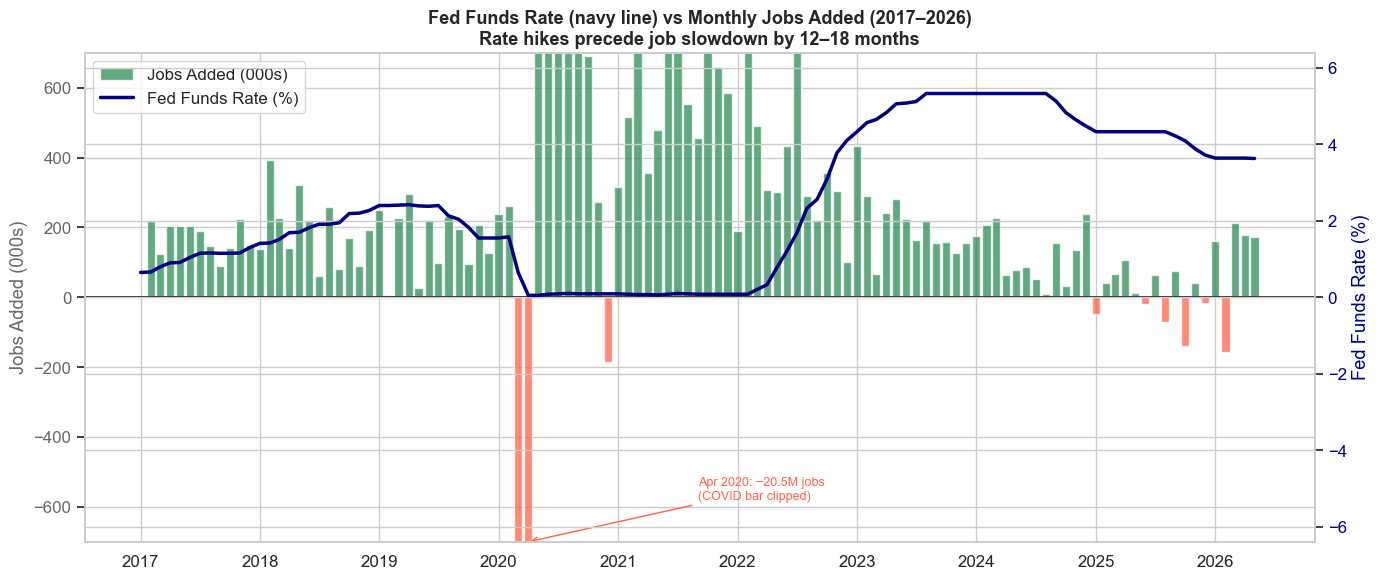

✅ Chart saved as fed_rate_vs_jobs.png


In [386]:
# ── Chart: Fed Funds Rate vs Monthly Jobs Added — Shared Zero Baseline ──

fig, ax2 = plt.subplots(figsize=(14, 6))

# Left axis: monthly jobs added as colour-coded bars
bar_colors = ['seagreen' if v > 0 else 'tomato' for v in df_payrolls['jobs_added_thousands']]
ax2.bar(df_payrolls['date'], df_payrolls['jobs_added_thousands'],
        color=bar_colors, width=25, alpha=0.75, label='Jobs Added (000s)')
ax2.axhline(0, color='black', linewidth=1.2)

# Symmetric limits so 0 sits at the exact centre of the left axis
y_jobs = 700
ax2.set_ylim(-y_jobs, y_jobs)
ax2.set_ylabel('Jobs Added (000s)', color='dimgray')
ax2.tick_params(axis='y', labelcolor='dimgray')

# Annotate the clipped COVID bar
ax2.annotate('Apr 2020: −20.5M jobs\n(COVID bar clipped)',
             xy=(pd.Timestamp('2020-04-01'), -y_jobs),
             xytext=(pd.Timestamp('2021-09-01'), -580),
             arrowprops=dict(arrowstyle='->', color='tomato'),
             fontsize=9, color='tomato')

# Right axis: Fed Funds Rate — symmetric limits so its 0 matches the left axis 0
ax2r = ax2.twinx()
ax2r.plot(df_fed['date'], df_fed['fed_funds_rate'],
          color='navy', linewidth=2.5, label='Fed Funds Rate (%)', zorder=5)

y_fed = df_fed['fed_funds_rate'].max() * 1.2
ax2r.set_ylim(-y_fed, y_fed)
ax2r.set_ylabel('Fed Funds Rate (%)', color='navy')
ax2r.tick_params(axis='y', labelcolor='navy')

# Merged legend for both axes
lines1, labels1 = ax2.get_legend_handles_labels()
lines2, labels2 = ax2r.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

ax2.set_title('Fed Funds Rate (navy line) vs Monthly Jobs Added (2017–2026)\n'
              'Rate hikes precede job slowdown by 12–18 months',
              fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('fed_rate_vs_jobs.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Chart saved as fed_rate_vs_jobs.png')

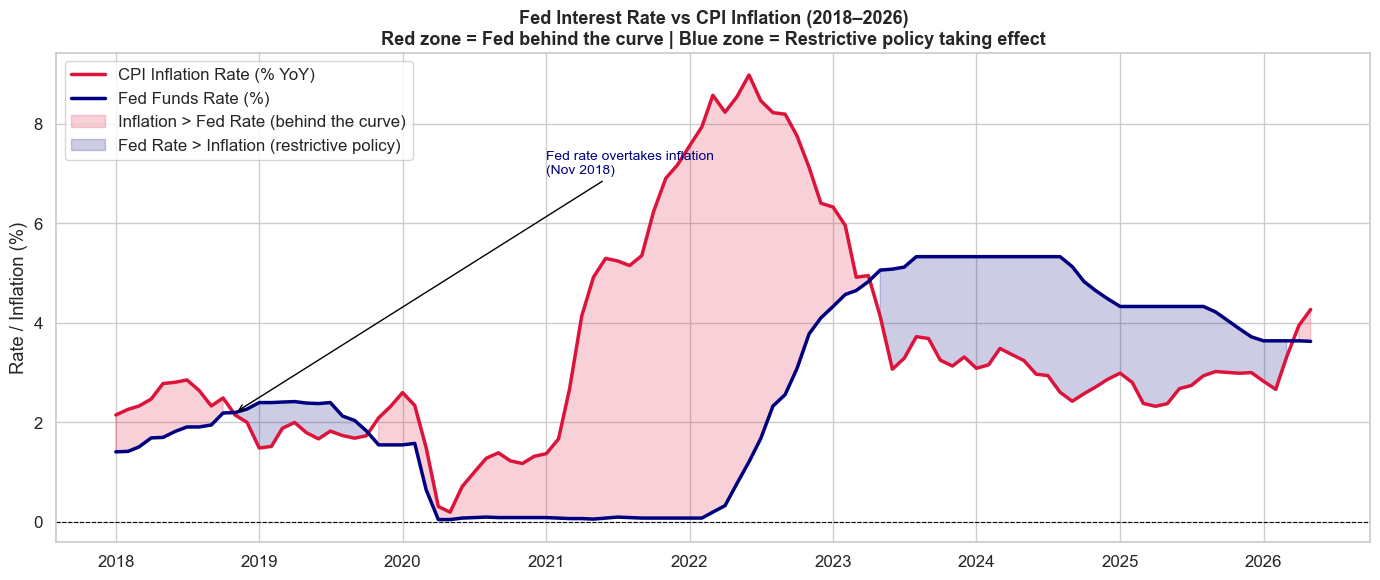

📊 Key Finding: Fed Policy Phases
   Months Fed was behind the curve: 54
   Months of restrictive policy:    46
   Widest gap (inflation - Fed rate): 8.4pp in Mar 2022


In [387]:
# ── Chart: Fed Interest Rate vs CPI Inflation — The Policy Response ──
# Both series are in % so they share one axis — the crossing points are the story.
#
# When inflation (red) > Fed rate (navy) → Fed is "behind the curve" (real rates negative)
# When Fed rate (navy) > inflation (red) → Fed is restrictive (real rates positive)
# The moment Fed rate crosses above CPI is when borrowing truly tightens.

# Align both series on matching dates
df_policy = df_fed[['date', 'fed_funds_rate']].merge(
    df_cpi[['date', 'inflation_rate_yoy']], on='date', how='inner'
)

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df_policy['date'], df_policy['inflation_rate_yoy'],
        color='crimson', linewidth=2.5, label='CPI Inflation Rate (% YoY)')
ax.plot(df_policy['date'], df_policy['fed_funds_rate'],
        color='navy', linewidth=2.5, label='Fed Funds Rate (%)')

# Red shading: inflation above Fed rate — Fed is behind the curve, money still cheap
ax.fill_between(df_policy['date'],
                df_policy['inflation_rate_yoy'], df_policy['fed_funds_rate'],
                where=df_policy['inflation_rate_yoy'] > df_policy['fed_funds_rate'],
                alpha=0.2, color='crimson', label='Inflation > Fed Rate (behind the curve)')

# Blue shading: Fed rate above inflation — policy is truly restrictive
ax.fill_between(df_policy['date'],
                df_policy['inflation_rate_yoy'], df_policy['fed_funds_rate'],
                where=df_policy['fed_funds_rate'] >= df_policy['inflation_rate_yoy'],
                alpha=0.2, color='navy', label='Fed Rate > Inflation (restrictive policy)')

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_ylabel('Rate / Inflation (%)')
ax.set_title('Fed Interest Rate vs CPI Inflation (2018–2026)\n'
             'Red zone = Fed behind the curve | Blue zone = Restrictive policy taking effect',
             fontsize=13, fontweight='bold')
ax.legend(loc='upper left')

# Annotate the crossover point where Fed rate finally overtook inflation
crossover = df_policy[df_policy['fed_funds_rate'] >= df_policy['inflation_rate_yoy']].iloc[0]
ax.annotate(
    f'Fed rate overtakes inflation\n({crossover["date"].strftime("%b %Y")})',
    xy=(crossover['date'], crossover['fed_funds_rate']),
    xytext=(pd.Timestamp('2021-01-01'), 7),
    arrowprops=dict(arrowstyle='->', color='black'),
    fontsize=10, color='navy'
)

plt.tight_layout()
plt.savefig('fed_rate_vs_cpi.png', dpi=150, bbox_inches='tight')
plt.show()

behind = df_policy[df_policy['inflation_rate_yoy'] > df_policy['fed_funds_rate']]
restrictive = df_policy[df_policy['fed_funds_rate'] >= df_policy['inflation_rate_yoy']]
print(f'📊 Key Finding: Fed Policy Phases')
print(f'   Months Fed was behind the curve: {len(behind)}')
print(f'   Months of restrictive policy:    {len(restrictive)}')
peak_gap = (df_policy['inflation_rate_yoy'] - df_policy['fed_funds_rate']).max()
peak_gap_date = df_policy.loc[(df_policy['inflation_rate_yoy'] - df_policy['fed_funds_rate']).idxmax(), 'date']
print(f'   Widest gap (inflation - Fed rate): {peak_gap:.1f}pp in {peak_gap_date.strftime("%b %Y")}')

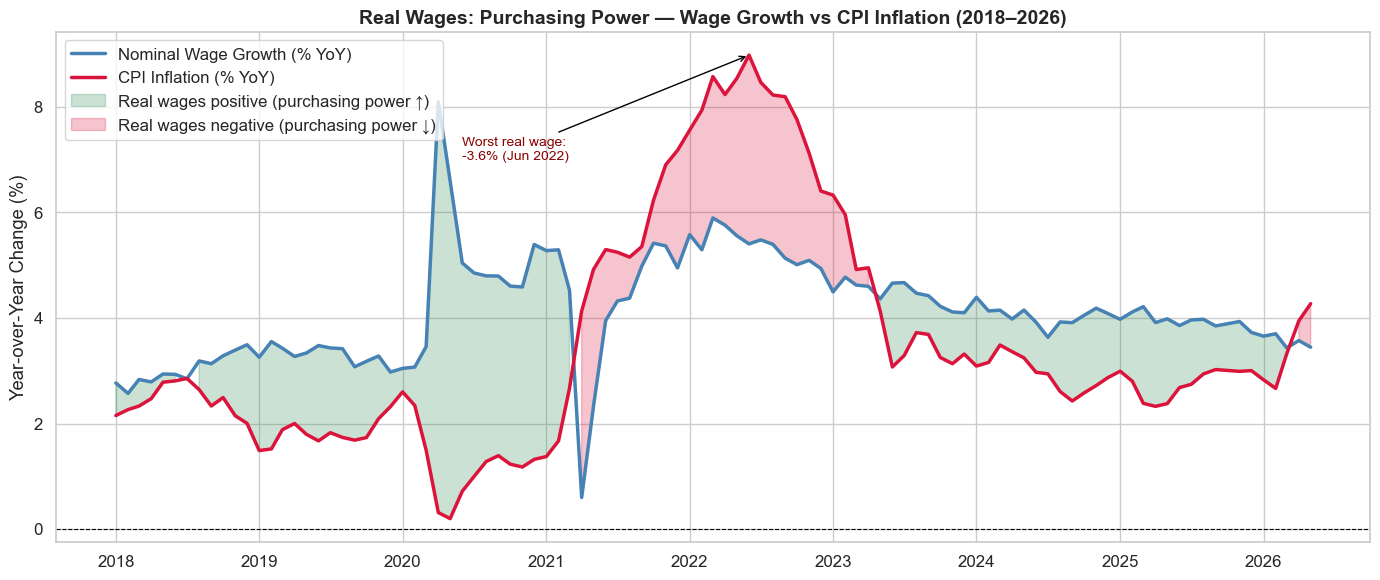

📊 Key Finding: Real Wages
   Worst purchasing power erosion: -3.6% in Jun 2022
   Workers effectively took a 3.6% pay cut in real terms
   → Less consumer spending → aggregate demand fell → hiring slowed


In [388]:
# ── Chart: Real Wages — Purchasing Power (Wage Growth vs CPI Inflation) ──

# Merge wage growth and inflation onto matching dates
df_real = df_wages[['date', 'wage_growth_yoy']].merge(
    df_cpi[['date', 'inflation_rate_yoy']], on='date', how='inner'
)

# Real wage growth = nominal wage growth minus inflation rate
# Positive → purchasing power rising; Negative → purchasing power eroding
df_real['real_wage_growth'] = df_real['wage_growth_yoy'] - df_real['inflation_rate_yoy']

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df_real['date'], df_real['wage_growth_yoy'],
        color='steelblue', linewidth=2.5, label='Nominal Wage Growth (% YoY)')
ax.plot(df_real['date'], df_real['inflation_rate_yoy'],
        color='crimson', linewidth=2.5, label='CPI Inflation (% YoY)')

# Green shading where wages beat inflation — purchasing power rising
ax.fill_between(df_real['date'],
                df_real['wage_growth_yoy'], df_real['inflation_rate_yoy'],
                where=df_real['wage_growth_yoy'] >= df_real['inflation_rate_yoy'],
                alpha=0.25, color='seagreen', label='Real wages positive (purchasing power ↑)')

# Red shading where inflation beats wages — purchasing power falling
ax.fill_between(df_real['date'],
                df_real['wage_growth_yoy'], df_real['inflation_rate_yoy'],
                where=df_real['wage_growth_yoy'] < df_real['inflation_rate_yoy'],
                alpha=0.25, color='crimson', label='Real wages negative (purchasing power ↓)')

ax.axhline(0, color='black', linewidth=0.8, linestyle='--')
ax.set_ylabel('Year-over-Year Change (%)')
ax.set_title('Real Wages: Purchasing Power — Wage Growth vs CPI Inflation (2018–2026)',
             fontsize=14, fontweight='bold')
ax.legend(loc='upper left')

# Annotate the worst real-wage period
worst_idx  = df_real['real_wage_growth'].idxmin()
worst_row  = df_real.loc[worst_idx]
ax.annotate(
    f'Worst real wage:\n{worst_row["real_wage_growth"]:.1f}% ({worst_row["date"].strftime("%b %Y")})',
    xy=(worst_row['date'], worst_row['inflation_rate_yoy']),
    xytext=(pd.Timestamp('2020-06-01'), 7),
    arrowprops=dict(arrowstyle='->', color='black'),
    fontsize=10, color='darkred'
)

plt.tight_layout()
plt.savefig('real_wages_purchasing_power.png', dpi=150, bbox_inches='tight')
plt.show()

peak_neg      = df_real['real_wage_growth'].min()
peak_neg_date = df_real.loc[df_real['real_wage_growth'].idxmin(), 'date']
print(f'📊 Key Finding: Real Wages')
print(f'   Worst purchasing power erosion: {peak_neg:.1f}% in {peak_neg_date.strftime("%b %Y")}')
print(f'   Workers effectively took a {abs(peak_neg):.1f}% pay cut in real terms')
print(f'   → Less consumer spending → aggregate demand fell → hiring slowed')

In [389]:
# ── Save Economic Indicator DataFrames to CSV ──
# Saved to the same power_bi_data/ folder as the other datasets.
# Each file follows the same convention: date, data columns, year.

import os
os.makedirs('power_bi_data', exist_ok=True)

# ── CPI / Inflation ──
df_cpi_export = df_cpi.copy()
df_cpi_export['year'] = df_cpi_export['date'].dt.year
df_cpi_export.to_csv('power_bi_data/cpi_inflation.csv', index=False)
print(f'✅ Saved cpi_inflation.csv          ({len(df_cpi_export)} rows)')

# ── Federal Funds Rate ──
df_fed_export = df_fed.copy()
df_fed_export['year'] = df_fed_export['date'].dt.year
df_fed_export.to_csv('power_bi_data/fed_funds_rate.csv', index=False)
print(f'✅ Saved fed_funds_rate.csv         ({len(df_fed_export)} rows)')

# ── Average Hourly Earnings ──
df_wages_export = df_wages.copy()
df_wages_export['year'] = df_wages_export['date'].dt.year
df_wages_export.to_csv('power_bi_data/avg_hourly_earnings.csv', index=False)
print(f'✅ Saved avg_hourly_earnings.csv    ({len(df_wages_export)} rows)')

print('\n📁 All three files saved to power_bi_data/')
print('   Columns saved:')
print(f'   cpi_inflation.csv        → {list(df_cpi_export.columns)}')
print(f'   fed_funds_rate.csv       → {list(df_fed_export.columns)}')
print(f'   avg_hourly_earnings.csv  → {list(df_wages_export.columns)}')

✅ Saved cpi_inflation.csv          (100 rows)
✅ Saved fed_funds_rate.csv         (113 rows)
✅ Saved avg_hourly_earnings.csv    (101 rows)

📁 All three files saved to power_bi_data/
   Columns saved:
   cpi_inflation.csv        → ['date', 'cpi', 'inflation_rate_yoy', 'year']
   fed_funds_rate.csv       → ['date', 'fed_funds_rate', 'year']
   avg_hourly_earnings.csv  → ['date', 'avg_hourly_earnings', 'wage_growth_yoy', 'year']


---
## 🧹 Section 3: Data Quality Check & Cleaning

Before visualizing, we always check for:
- **Missing values** (`NaN` — Not a Number)
- **Correct data types** (dates should be `datetime`, numbers should be `float` or `int`)
- **Outliers or anomalies** that might distort our charts

This step is critical in real-world data analysis — dirty data produces misleading results.

In [390]:
# ── Data Quality Report ──

def data_quality_report(df: pd.DataFrame, name: str) -> None:
    """
    Prints a summary of a DataFrame's shape, data types, and missing values.

    This is a function we're defining ourselves — it's just a reusable block of
    code we can call on any DataFrame.
    """
    print(f'━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')
    print(f' Dataset: {name}')
    print(f'━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━')
    print(f' Rows: {df.shape[0]}  |  Columns: {df.shape[1]}')
    print()

    # Loop through each column and report its type and null count
    for col in df.columns:
        n_null = df[col].isnull().sum()  # Count how many values are missing
        dtype  = df[col].dtype           # The data type (float64, datetime64, object, etc.)
        null_str = f'⚠️  {n_null} missing' if n_null > 0 else '✅ No missing'
        print(f'  {col:<35} dtype={str(dtype):<15} {null_str}')
    print()


# Run the quality check on all three datasets
data_quality_report(df_unemployment, 'Unemployment Rate')
data_quality_report(df_payrolls,     'Nonfarm Payrolls')
data_quality_report(df_industry,     'Industry Employment')
data_quality_report(df_occupations,  'Top Occupations (OES)')

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 Dataset: Unemployment Rate
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 Rows: 112  |  Columns: 2

  date                                dtype=datetime64[ns]  ✅ No missing
  unemployment_rate                   dtype=float64         ✅ No missing

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 Dataset: Nonfarm Payrolls
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 Rows: 112  |  Columns: 3

  date                                dtype=datetime64[ns]  ✅ No missing
  total_employed_thousands            dtype=float64         ✅ No missing
  jobs_added_thousands                dtype=float64         ✅ No missing

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 Dataset: Industry Employment
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
 Rows: 1130  |  Columns: 3

  date                                dtype=datetime64[ns]  ✅ No missing
  employed_thousands                  dtype=float64         ✅ No missing
  industry                            dtype=object          ✅ No missing



In [391]:
# ── Descriptive Statistics ──
# .describe() gives count, mean, std deviation, min, quartiles, and max
# This helps spot outliers — e.g., the COVID spike in unemployment

print('=== Unemployment Rate — Summary Statistics ===')
print(df_unemployment['unemployment_rate'].describe().round(2))

print('\n=== Monthly Job Change (thousands) — Summary Statistics ===')
print(df_payrolls['jobs_added_thousands'].describe().round(0))

print('\n=== Top Occupation Wages — Summary Statistics ===')
print(df_occupations['Median_Annual_Wage'].describe().round(0))

=== Unemployment Rate — Summary Statistics ===
count    112.00
mean       4.54
std        1.78
min        3.40
25%        3.70
50%        4.05
75%        4.40
max       14.80
Name: unemployment_rate, dtype: float64

=== Monthly Job Change (thousands) — Summary Statistics ===
count      112.0
mean       119.0
std       2044.0
min     -20469.0
25%         94.0
50%        204.0
75%        302.0
max       4631.0
Name: jobs_added_thousands, dtype: float64

=== Top Occupation Wages — Summary Statistics ===
count        20.0
mean      52942.0
std       28587.0
min       30710.0
25%       35115.0
50%       40730.0
75%       56660.0
max      132270.0
Name: Median_Annual_Wage, dtype: float64


---
## 📈 Section 4: Unemployment Rate Over Time

The unemployment rate measures the share of the labour force that is jobless but actively seeking work. Our 2017–2026 window captures the most dramatic economic cycle in modern U.S. history across three distinct phases:

| Phase | Period | What Happened |
|---|---|---|
| Pre-pandemic boom | 2017–2019 | Unemployment fell to a **50-year low of 3.5%** — end of the longest expansion on record |
| COVID-19 crash | Mar–Apr 2020 | Spiked to **14.7%** in a single month — worst since the Great Depression |
| Recovery & normalization | 2021–2026 | Fastest jobs recovery on record; Fed raised rates 11× to control inflation |

The charts below annotate each of these events to make the story immediately readable.

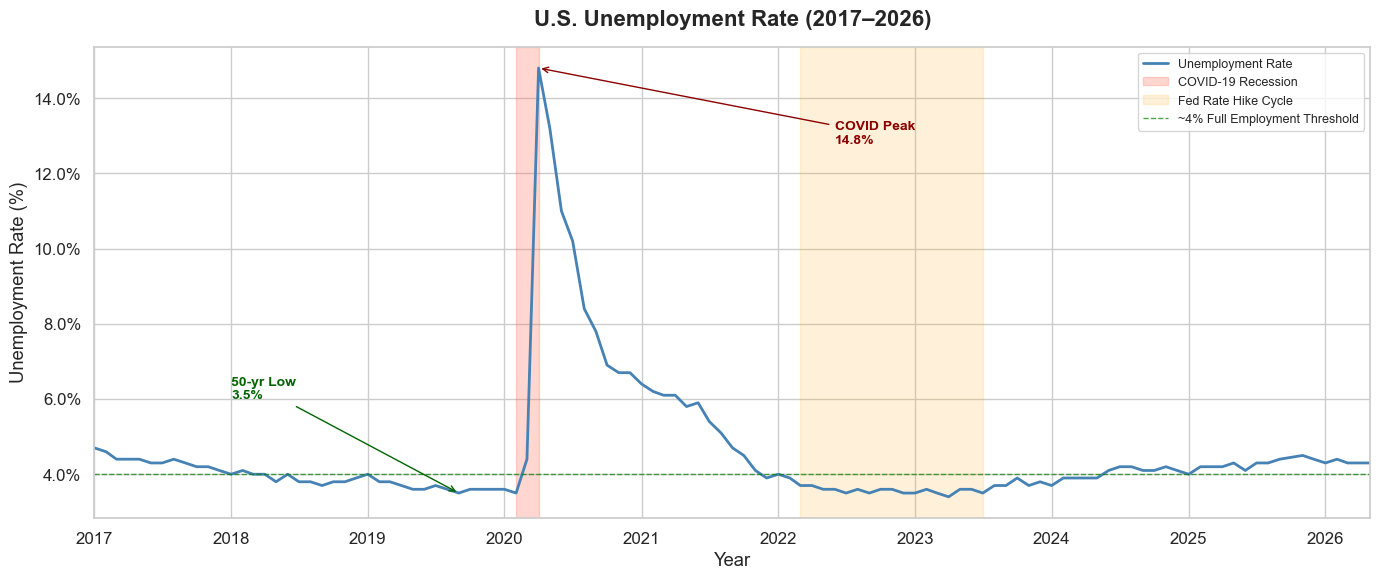

Chart saved as unemployment_rate.png


In [392]:
# ── Plot: U.S. Unemployment Rate ──

start_yr = df_unemployment['date'].min().year
end_yr   = df_unemployment['date'].max().year

fig, ax = plt.subplots(figsize=(14, 6))

ax.plot(df_unemployment['date'],
        df_unemployment['unemployment_rate'],
        color='steelblue', linewidth=2, label='Unemployment Rate')

# ── Shade the COVID recession (Feb–Apr 2020) ──
ax.axvspan(pd.Timestamp('2020-02-01'), pd.Timestamp('2020-04-01'),
           alpha=0.25, color='tomato', label='COVID-19 Recession')

# ── Shade the Fed rate-hike cycle (Mar 2022 – Jul 2023) ──
ax.axvspan(pd.Timestamp('2022-03-01'), pd.Timestamp('2023-07-01'),
           alpha=0.15, color='orange', label='Fed Rate Hike Cycle')

# ── Full-employment reference line ──
ax.axhline(y=4.0, color='green', linestyle='--', linewidth=1, alpha=0.7,
           label='~4% Full Employment Threshold')

# ── Annotate the COVID peak ──
covid_peak_date = df_unemployment.loc[df_unemployment['unemployment_rate'].idxmax(), 'date']
covid_peak_val  = df_unemployment['unemployment_rate'].max()

ax.annotate(
    f'COVID Peak\n{covid_peak_val}%',
    xy=(covid_peak_date, covid_peak_val),
    xytext=(pd.Timestamp('2022-06-01'), covid_peak_val - 2),
    fontsize=10, color='darkred', fontweight='bold',
    arrowprops=dict(arrowstyle='->', color='darkred')
)

# ── Annotate the pre-pandemic low ──
pre_covid = df_unemployment[df_unemployment['date'] < '2020-01-01']
low_date = pre_covid.loc[pre_covid['unemployment_rate'].idxmin(), 'date']
low_val  = pre_covid['unemployment_rate'].min()

ax.annotate(
    f'50-yr Low\n{low_val}%',
    xy=(low_date, low_val),
    xytext=(pd.Timestamp('2018-01-01'), low_val + 2.5),
    fontsize=10, color='darkgreen', fontweight='bold',
    arrowprops=dict(arrowstyle='->', color='darkgreen')
)

# ── Labels and formatting ──
ax.set_title(f'U.S. Unemployment Rate ({start_yr}–{end_yr})', fontsize=16, fontweight='bold', pad=15)
ax.set_xlabel('Year')
ax.set_ylabel('Unemployment Rate (%)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.legend(loc='upper right', fontsize=9)
ax.set_xlim(df_unemployment['date'].min(), df_unemployment['date'].max())

plt.tight_layout()
plt.savefig('unemployment_rate.png', dpi=150, bbox_inches='tight')
plt.show()
print('Chart saved as unemployment_rate.png')

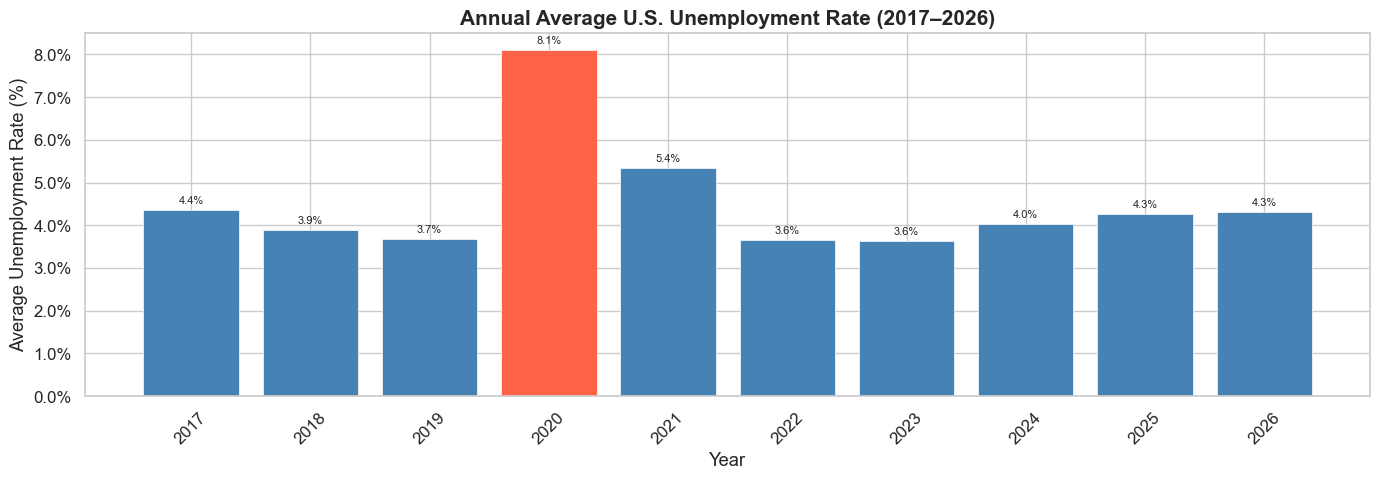

In [393]:
# ── Annual Average Unemployment Rate — Bar Chart ──
# This aggregates the monthly data to annual averages,
# which is easier to read in presentations

start_yr = df_unemployment['date'].min().year
end_yr   = df_unemployment['date'].max().year

# .dt.year extracts just the year from a datetime column
df_unemployment['year'] = df_unemployment['date'].dt.year

# Group by year and compute the mean (average) unemployment rate
df_annual_unemp = (
    df_unemployment
    .groupby('year')['unemployment_rate']
    .mean()
    .reset_index()
    .rename(columns={'unemployment_rate': 'avg_rate'})
)

# ── Build the bar chart ──
fig, ax = plt.subplots(figsize=(14, 5))

# COVID year (2020) in red, all others in steelblue
bar_colors = ['tomato' if yr == 2020 else 'steelblue' for yr in df_annual_unemp['year']]

bars = ax.bar(df_annual_unemp['year'], df_annual_unemp['avg_rate'],
              color=bar_colors, edgecolor='white', linewidth=0.5)

# Add value labels on top of each bar
for bar, val in zip(bars, df_annual_unemp['avg_rate']):
    ax.text(bar.get_x() + bar.get_width() / 2,
            bar.get_height() + 0.1,
            f'{val:.1f}%',
            ha='center', va='bottom', fontsize=8)

ax.set_title(f'Annual Average U.S. Unemployment Rate ({start_yr}–{end_yr})', fontsize=15, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Average Unemployment Rate (%)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xticks(df_annual_unemp['year'])
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('unemployment_annual.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 💼 Section 5: Monthly Jobs Added — Nonfarm Payrolls

The **monthly nonfarm payrolls report** is the most closely watched economic release in the world, published on the first Friday of every month. It tells us whether the economy is expanding (creating jobs) or contracting (destroying them).

- 🟩 **Green bars** — net jobs gained that month (economy growing)
- 🟥 **Red bars** — net jobs lost that month (economy contracting)

**What to look for in this chart:**
- The unprecedented April 2020 collapse (≈ −20 million jobs in a single month)
- The equally historic May 2020 rebound as lockdowns lifted
- The gradual cooling from 2023 onward as rate hikes filtered through the economy

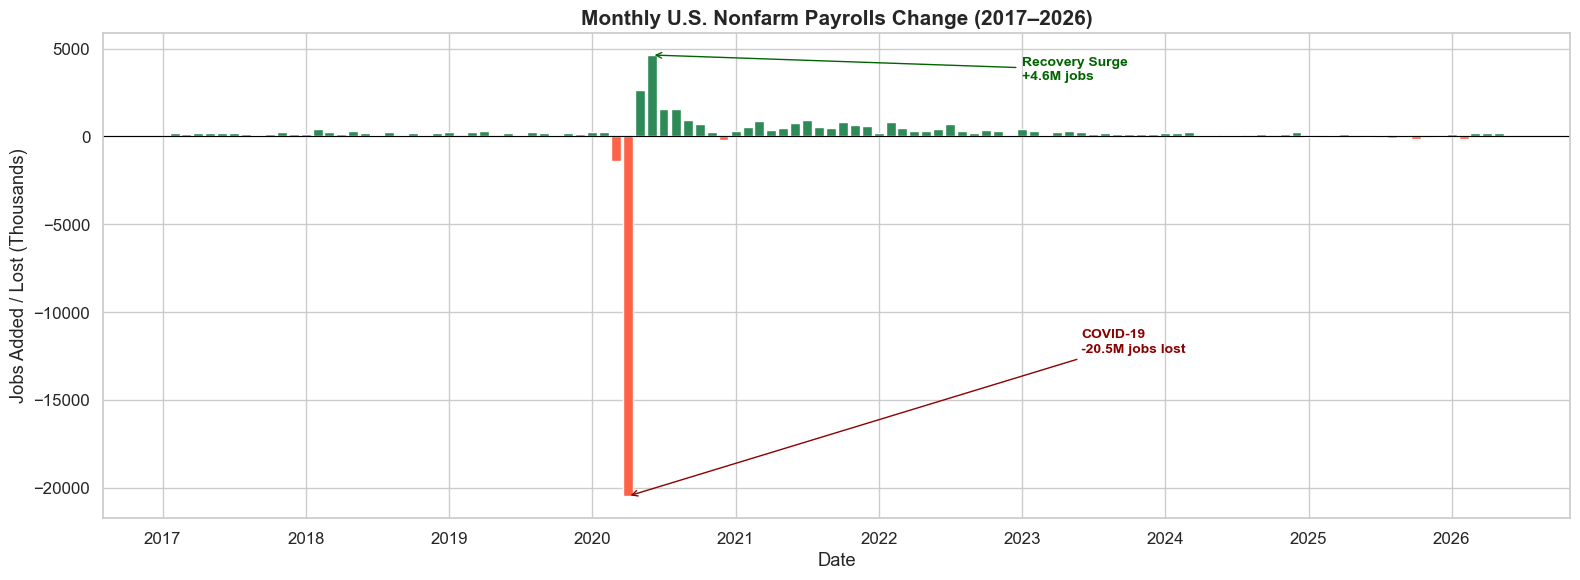

Total jobs added 2017–2026: 13.4 million


In [394]:
# ── Plot: Monthly Jobs Added (Nonfarm Payrolls) ──

start_yr = df_payrolls['date'].min().year
end_yr   = df_payrolls['date'].max().year

fig, ax = plt.subplots(figsize=(16, 6))

# Color each bar: green if jobs added, red if jobs lost
bar_colors = ['seagreen' if v > 0 else 'tomato' for v in df_payrolls['jobs_added_thousands']]

ax.bar(df_payrolls['date'],
       df_payrolls['jobs_added_thousands'],
       color=bar_colors,
       width=25)

ax.axhline(0, color='black', linewidth=0.8)

# ── Annotate the COVID collapse ──
covid_drop      = df_payrolls['jobs_added_thousands'].min()
covid_drop_date = df_payrolls.loc[df_payrolls['jobs_added_thousands'].idxmin(), 'date']

ax.annotate(
    f'COVID-19\n{covid_drop/1000:,.1f}M jobs lost',
    xy=(covid_drop_date, covid_drop),
    xytext=(pd.Timestamp('2023-06-01'), covid_drop * 0.6),
    fontsize=10, color='darkred', fontweight='bold',
    arrowprops=dict(arrowstyle='->', color='darkred')
)

# ── Annotate the COVID recovery surge ──
covid_gain      = df_payrolls['jobs_added_thousands'].max()
covid_gain_date = df_payrolls.loc[df_payrolls['jobs_added_thousands'].idxmax(), 'date']

ax.annotate(
    f'Recovery Surge\n+{covid_gain/1000:,.1f}M jobs',
    xy=(covid_gain_date, covid_gain),
    xytext=(pd.Timestamp('2023-01-01'), covid_gain * 0.7),
    fontsize=10, color='darkgreen', fontweight='bold',
    arrowprops=dict(arrowstyle='->', color='darkgreen')
)

ax.set_title(f'Monthly U.S. Nonfarm Payrolls Change ({start_yr}–{end_yr})', fontsize=15, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Jobs Added / Lost (Thousands)')
plt.tight_layout()
plt.savefig('nonfarm_payrolls.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Total jobs added {start_yr}–{end_yr}: {df_payrolls["jobs_added_thousands"].sum()/1000:,.1f} million')

---
## 🏆 Section 6: Top Occupations by Employment

The BLS Occupational Employment & Wage Statistics (OES) survey covers over 800 job titles. This section focuses on the **top 20 by total employment** to answer three questions:

1. Which occupations employ the most Americans?
2. Is there a relationship between how many people do a job and what it pays?
3. Which broad categories — healthcare, technology, retail — dominate the workforce?

> 📌 **Notable shift in May 2024:** Home Health & Personal Care Aides overtook Retail Salespersons as the single largest occupation in the U.S. — a direct reflection of the country's rapidly aging population.

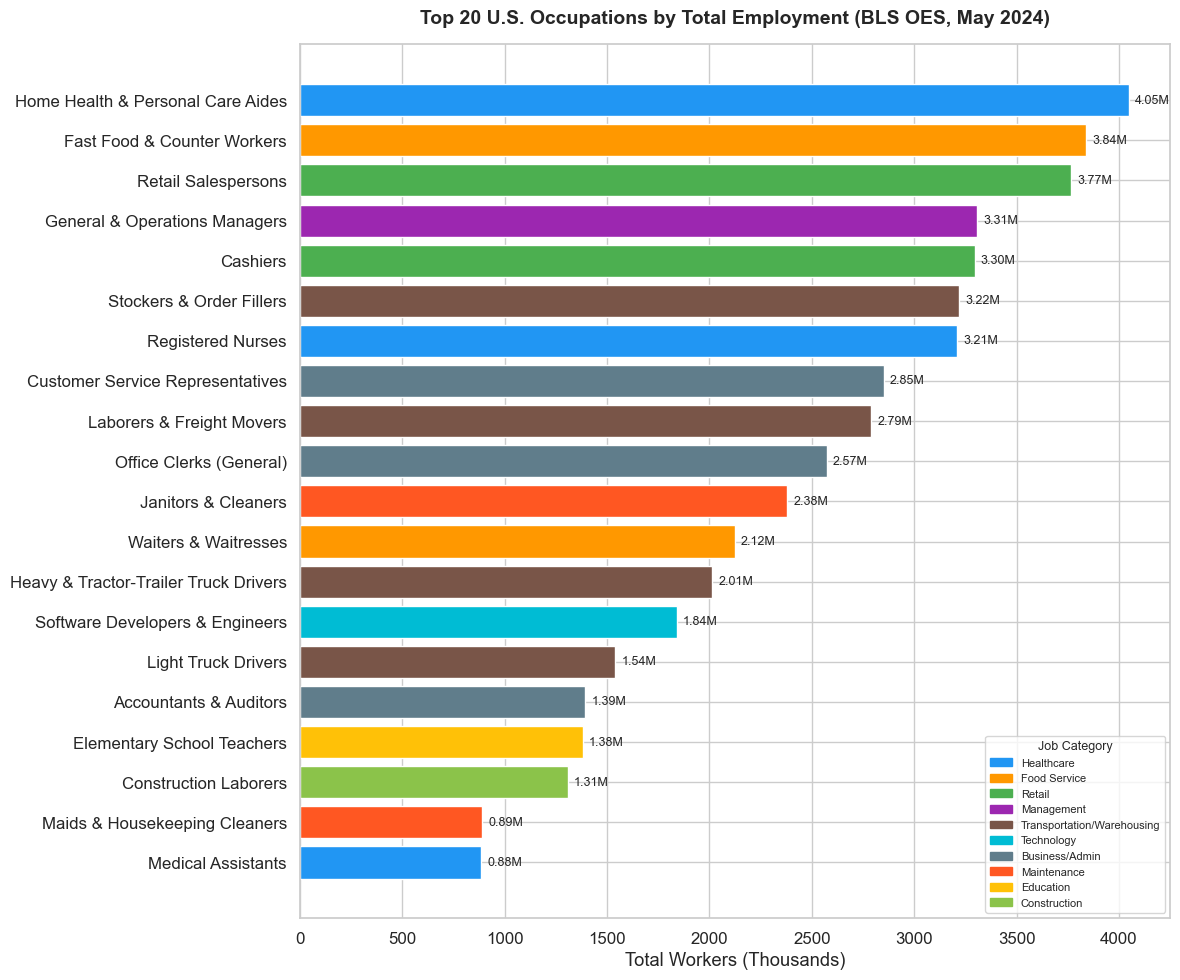

In [395]:
# ── Chart: Top 20 Occupations by Total Employment ──

# Define colors for each job category
CATEGORY_COLORS = {
    'Healthcare':                 '#2196F3',
    'Food Service':               '#FF9800',
    'Retail':                     '#4CAF50',
    'Management':                 '#9C27B0',
    'Transportation/Warehousing': '#795548',
    'Technology':                 '#00BCD4',
    'Business/Admin':             '#607D8B',
    'Maintenance':                '#FF5722',
    'Education':                  '#FFC107',
    'Construction':               '#8BC34A'
}

# Map a color to each row based on its Category
bar_colors = [CATEGORY_COLORS[cat] for cat in df_occupations['Category']]

fig, ax = plt.subplots(figsize=(12, 10))

# Horizontal bar chart — easier to read long occupation names
bars = ax.barh(df_occupations['Occupation'],
               df_occupations['Employment_Thousands'],
               color=bar_colors, edgecolor='white')

# Reverse y-axis so the highest-employment occupation is at the top
ax.invert_yaxis()

# Add data labels at the end of each bar
for bar, val in zip(bars, df_occupations['Employment_Thousands']):
    ax.text(bar.get_width() + 30,
            bar.get_y() + bar.get_height()/2,
            f'{val/1000:.2f}M',
            va='center', fontsize=9)

# ── Add a custom legend for categories ──
from matplotlib.patches import Patch
legend_handles = [Patch(color=c, label=k) for k, c in CATEGORY_COLORS.items()]
ax.legend(handles=legend_handles, title='Job Category',
          loc='lower right', fontsize=8, title_fontsize=9)

ax.set_title('Top 20 U.S. Occupations by Total Employment (BLS OES, May 2024)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Total Workers (Thousands)')
ax.set_ylabel('')
plt.tight_layout()
plt.savefig('top_occupations.png', dpi=150, bbox_inches='tight')
plt.show()

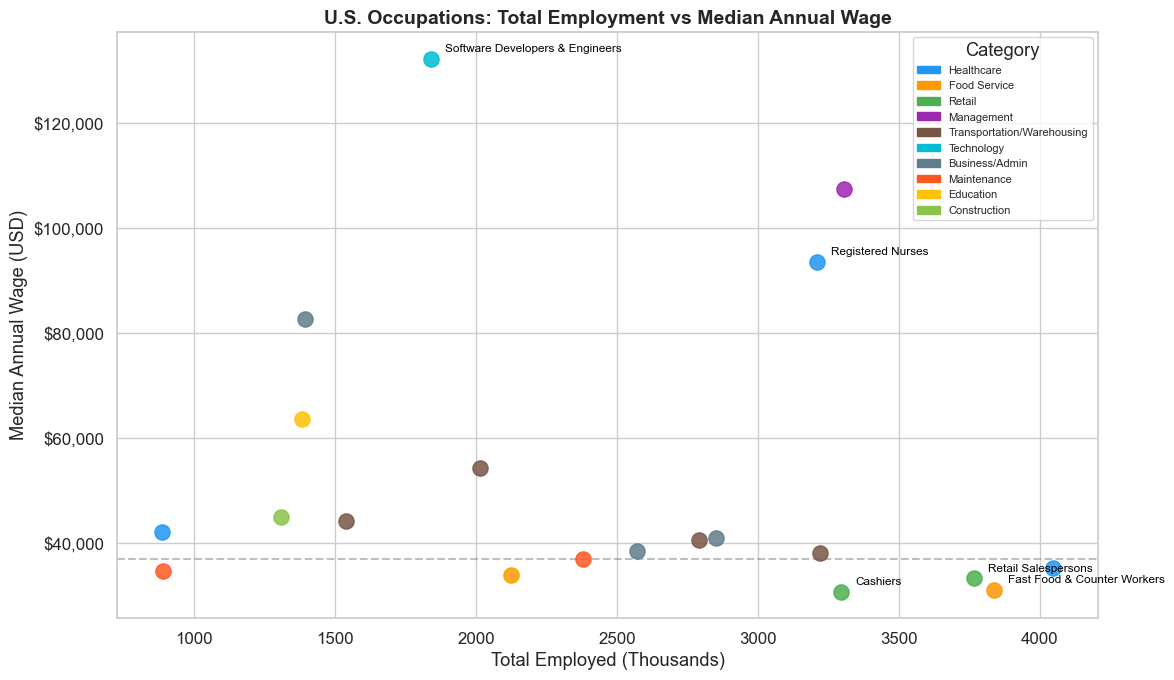

📊 Key Insight: High-employment jobs (food service, retail) tend to pay BELOW median,
   while lower-employment jobs (software, nursing) earn significantly more.


In [396]:
# ── Chart: Employment vs. Median Wage Scatter Plot ──
# This reveals an important insight: the highest-employment jobs are often the LOWEST paid

fig, ax = plt.subplots(figsize=(12, 7))

# Draw one dot per occupation, sized by employment, colored by category
for _, row in df_occupations.iterrows():
    ax.scatter(
        row['Employment_Thousands'],
        row['Median_Annual_Wage'],
        s=120,                                      # dot size
        color=CATEGORY_COLORS[row['Category']],
        alpha=0.85,
        zorder=3
    )

# Add text labels for key occupations
labels_to_show = [
    'Registered Nurses', 'Software Developers & Engineers',
    'Fast Food & Counter Workers', 'Retail Salespersons', 'Cashiers'
]
for _, row in df_occupations[df_occupations['Occupation'].isin(labels_to_show)].iterrows():
    ax.annotate(
        row['Occupation'],
        xy=(row['Employment_Thousands'], row['Median_Annual_Wage']),
        xytext=(10, 5), textcoords='offset points',
        fontsize=8.5, color='black'
    )

# Add reference lines for visual context
ax.axhline(y=37000, color='gray', linestyle='--', alpha=0.5, label='~$37K median U.S. wage')

ax.set_title('U.S. Occupations: Total Employment vs Median Annual Wage',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Total Employed (Thousands)')
ax.set_ylabel('Median Annual Wage (USD)')
ax.yaxis.set_major_formatter(lambda x, _: f'${x:,.0f}')

# Add category legend
ax.legend(handles=legend_handles, title='Category', fontsize=8, loc='upper right')
plt.tight_layout()
plt.savefig('occupation_wage_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

print('📊 Key Insight: High-employment jobs (food service, retail) tend to pay BELOW median,')
print('   while lower-employment jobs (software, nursing) earn significantly more.')

---
## 🏭 Section 7: Industry Hiring Trends (2017–2026)

Employment across 10 major sectors reveals which parts of the economy absorbed the COVID shock and which have yet to fully recover.

**Key findings previewed below:**

| Sector | COVID Impact | Recovery Path |
|---|---|---|
| Leisure & Hospitality | Deepest collapse (≈ −50%) | Fastest and most complete rebound |
| Education & Health Services | Brief dip | Steady long-run growth — driven by demographics |
| Information (Tech) | Moderate drop | Strong recovery, then notable layoffs in 2022–23 |
| Manufacturing | Significant losses | Slow, incomplete recovery amid automation |
| Government | Modest decline | Gradual recovery, then contraction in 2025–26 |

In [397]:
# ── Pivot the industry data for easier plotting ──
# Right now df_industry is in 'long' format (one row per industry per month)
# We'll convert to 'wide' format (one column per industry, one row per month)
#
# Long format:                   Wide format:
#   date | industry | employed      date | Construction | Manufacturing | ...
#   2000 | Constr.  | 6200      →   2000 | 6200         | 17000         | ...
#   2000 | Mfg.     | 17000         2001 | 6300         | 16800         | ...

df_industry_wide = df_industry.pivot_table(
    index='date',          # rows = dates
    columns='industry',    # columns = industries
    values='employed_thousands'
).reset_index()

print('✅ Pivoted to wide format:')
print(f'   Rows: {df_industry_wide.shape[0]}  |  Columns: {df_industry_wide.shape[1]}')
df_industry_wide.head(3)

✅ Pivoted to wide format:
   Rows: 113  |  Columns: 11


industry,date,Construction,Education & Health Services,Financial Activities,Government,Information,Leisure & Hospitality,Manufacturing,Mining & Logging,Professional & Business Services,"Trade, Transport & Utilities"
0,2017-01-01,6840.0,22941.0,8397.0,22316.0,2821.0,15874.0,12334.0,647.0,20415.0,27314.0
1,2017-02-01,6881.0,23018.0,8398.0,22326.0,2815.0,15917.0,12350.0,656.0,20433.0,27311.0
2,2017-03-01,6902.0,23047.0,8408.0,22329.0,2813.0,15941.0,12361.0,660.0,20463.0,27298.0


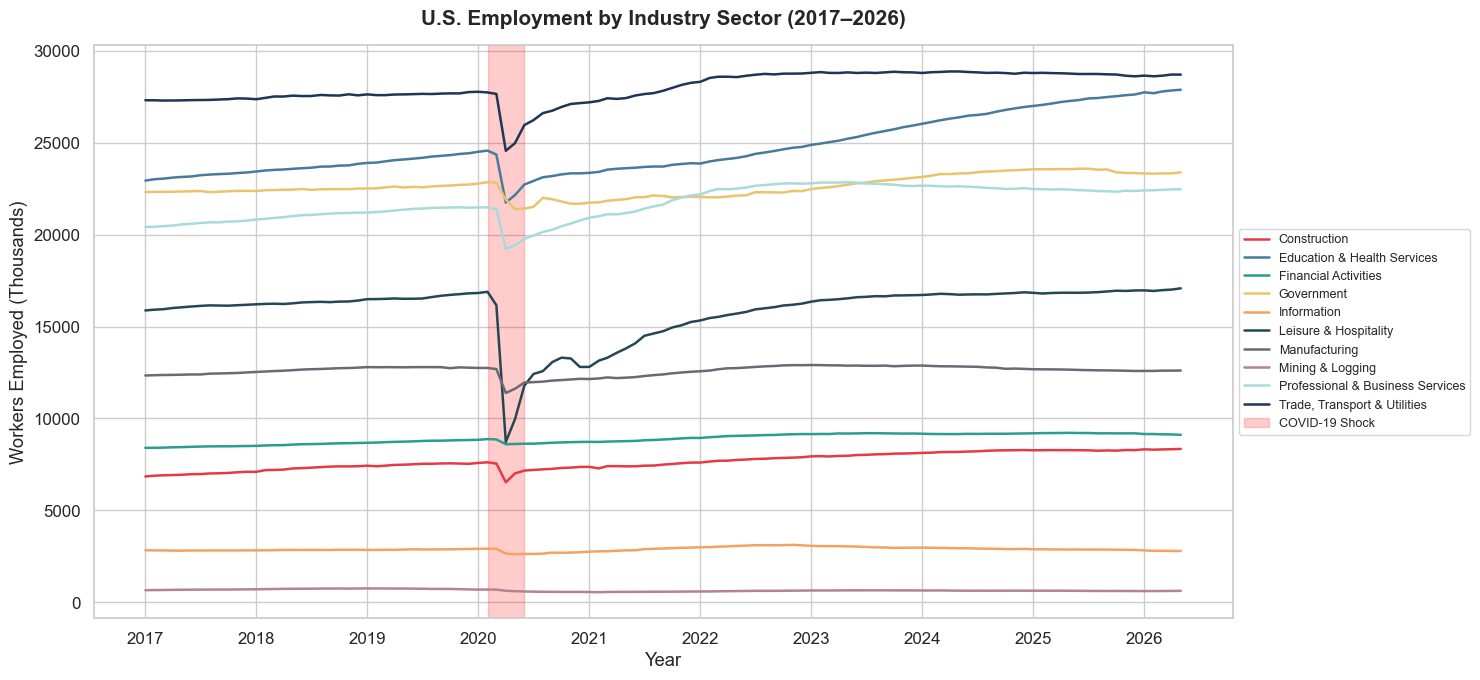

In [398]:
# ── Chart: Industry Employment Trends (Line Chart) ──

start_yr = df_industry['date'].min().year
end_yr   = df_industry['date'].max().year

# Get just the industry columns (exclude 'date')
industry_cols = [c for c in df_industry_wide.columns if c != 'date']

# Define distinct colors for each industry
industry_colors = [
    '#E63946', '#457B9D', '#2A9D8F', '#E9C46A', '#F4A261',
    '#264653', '#6D6875', '#B5838D', '#A8DADC', '#1D3557'
]

fig, ax = plt.subplots(figsize=(15, 7))

for col, color in zip(industry_cols, industry_colors):
    ax.plot(df_industry_wide['date'],
            df_industry_wide[col],
            label=col,
            linewidth=1.8,
            color=color)

# Shade the COVID shock period
ax.axvspan(pd.Timestamp('2020-02-01'), pd.Timestamp('2020-06-01'),
           alpha=0.2, color='red', label='COVID-19 Shock')

ax.set_title(f'U.S. Employment by Industry Sector ({start_yr}–{end_yr})',
             fontsize=15, fontweight='bold', pad=15)
ax.set_xlabel('Year')
ax.set_ylabel('Workers Employed (Thousands)')
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), fontsize=9)
plt.tight_layout()
plt.savefig('industry_trends.png', dpi=150, bbox_inches='tight')
plt.show()

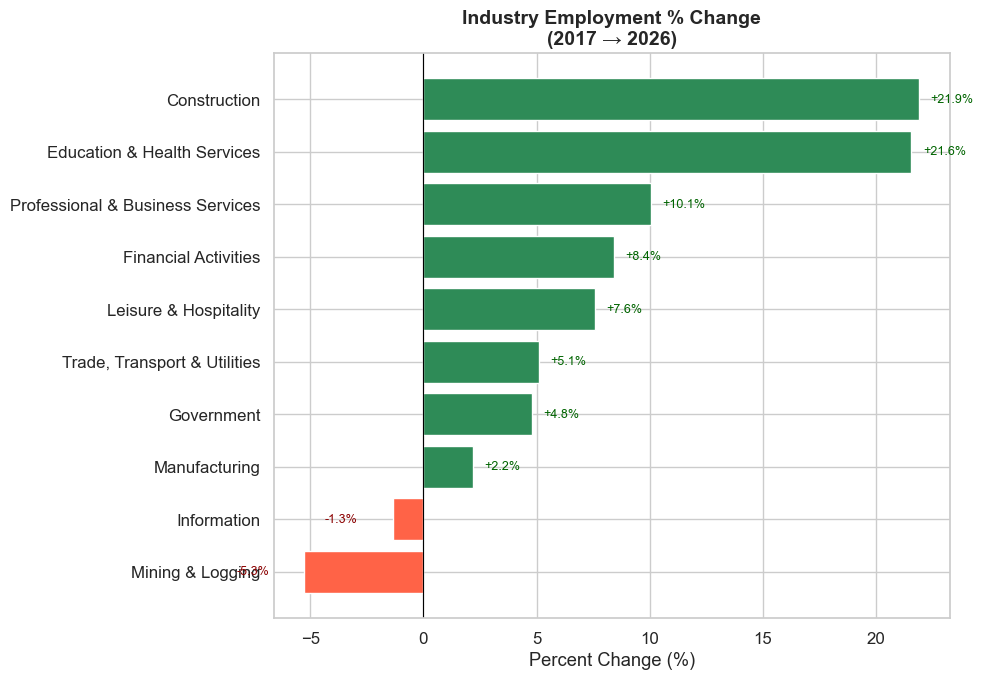

In [399]:
# ── Chart: Industry Employment % Change (start vs end of our data window) ──
# Instead of absolute numbers, let's look at PERCENT change:
# Which industry grew the MOST vs LEAST since 2017?

# Get the first and last available data point for each industry
df_first = df_industry[df_industry['date'] == df_industry['date'].min()].set_index('industry')['employed_thousands']
df_last  = df_industry[df_industry['date'] == df_industry['date'].max()].set_index('industry')['employed_thousands']

# Calculate percentage change: ((new - old) / old) * 100
pct_change = ((df_last - df_first) / df_first * 100).sort_values()

# Build the horizontal bar chart
fig, ax = plt.subplots(figsize=(10, 7))

bar_colors = ['tomato' if v < 0 else 'seagreen' for v in pct_change]
bars = ax.barh(pct_change.index, pct_change.values, color=bar_colors, edgecolor='white')

# Add labels
for bar, val in zip(bars, pct_change.values):
    offset = 0.5 if val >= 0 else -3
    ax.text(val + offset, bar.get_y() + bar.get_height()/2,
            f'{val:+.1f}%', va='center', fontsize=9,
            color='darkgreen' if val >= 0 else 'darkred')

ax.axvline(0, color='black', linewidth=0.8)
ax.set_title(f'Industry Employment % Change\n({df_industry["date"].min().year} → {df_industry["date"].max().year})',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Percent Change (%)')
plt.tight_layout()
plt.savefig('industry_growth.png', dpi=150, bbox_inches='tight')
plt.show()

---
## 🔍 Section 8: Causes of Unemployment

Economists classify unemployment into four types. Understanding the type helps identify the correct policy response.

| Type | Definition | Example |
|---|---|---|
| **Frictional** | Short-term between jobs | A worker who quit to search for a better role |
| **Structural** | Skills no longer match available jobs | A factory worker displaced by automation |
| **Cyclical** | Caused by an economic downturn | Mass layoffs during the 2020 COVID recession |
| **Seasonal** | Predictable calendar-driven patterns | Holiday retail workers laid off in January |

Our 2017–2026 data shows two clear episodes of **cyclical unemployment**:

| Episode | Trigger | Labour Market Effect |
|---|---|---|
| COVID-19 (2020) | Government lockdowns and demand collapse | Unemployment surged from 3.5% → 14.7% in 2 months |
| Fed rate hikes (2022–23) | Inflation hit 40-year highs; 11 consecutive rate increases | Unemployment rose gently from 3.4% → ~4.3% — a rare soft landing |

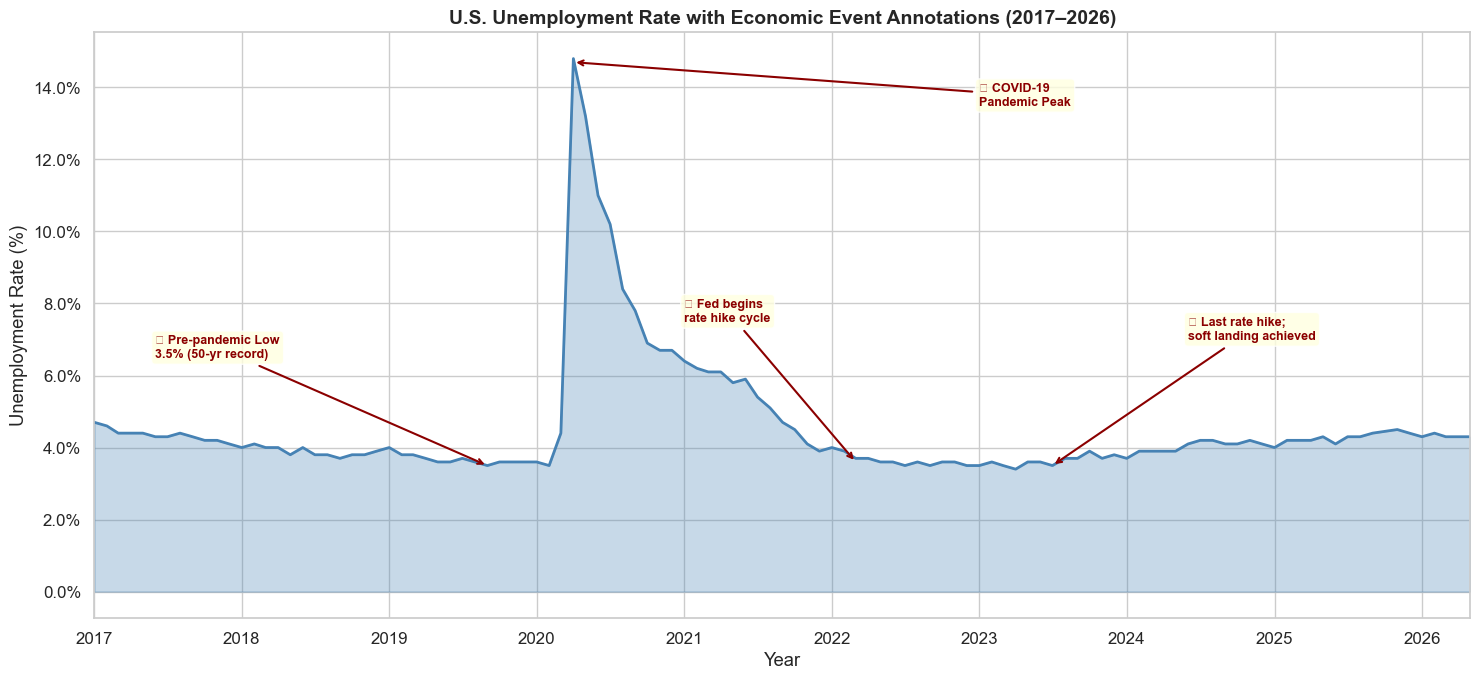

In [400]:
# ── Annotated Chart: Causes of Unemployment Changes ──

start_yr = df_unemployment['date'].min().year
end_yr   = df_unemployment['date'].max().year

# Key events that caused notable unemployment changes in our window
events = [
    {
        'date': '2019-09-01',
        'label': '① Pre-pandemic Low\n3.5% (50-yr record)',
        'y': 3.5,
        'xtxt': '2017-06-01',
        'ytxt': 6.5
    },
    {
        'date': '2020-04-01',
        'label': '② COVID-19\nPandemic Peak',
        'y': 14.7,
        'xtxt': '2023-01-01',
        'ytxt': 13.5
    },
    {
        'date': '2022-03-01',
        'label': '③ Fed begins\nrate hike cycle',
        'y': 3.6,
        'xtxt': '2021-01-01',
        'ytxt': 7.5
    },
    {
        'date': '2023-07-01',
        'label': '④ Last rate hike;\nsoft landing achieved',
        'y': 3.5,
        'xtxt': '2024-06-01',
        'ytxt': 7.0
    }
]

fig, ax = plt.subplots(figsize=(15, 7))

ax.fill_between(df_unemployment['date'],
                df_unemployment['unemployment_rate'],
                alpha=0.3, color='steelblue')

ax.plot(df_unemployment['date'],
        df_unemployment['unemployment_rate'],
        color='steelblue', linewidth=2)

for ev in events:
    # Only annotate if the date is within our data range
    ev_date = pd.Timestamp(ev['date'])
    if ev_date < df_unemployment['date'].min() or ev_date > df_unemployment['date'].max():
        continue
    ax.annotate(
        ev['label'],
        xy=(ev_date, ev['y']),
        xytext=(pd.Timestamp(ev['xtxt']), ev['ytxt']),
        fontsize=9, fontweight='bold',
        arrowprops=dict(arrowstyle='->', color='darkred', lw=1.5),
        color='darkred',
        bbox=dict(boxstyle='round,pad=0.3', fc='lightyellow', alpha=0.8)
    )

ax.set_title(f'U.S. Unemployment Rate with Economic Event Annotations ({start_yr}–{end_yr})',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Year')
ax.set_ylabel('Unemployment Rate (%)')
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_xlim(df_unemployment['date'].min(), df_unemployment['date'].max())
plt.tight_layout()
plt.savefig('unemployment_causes.png', dpi=150, bbox_inches='tight')
plt.show()

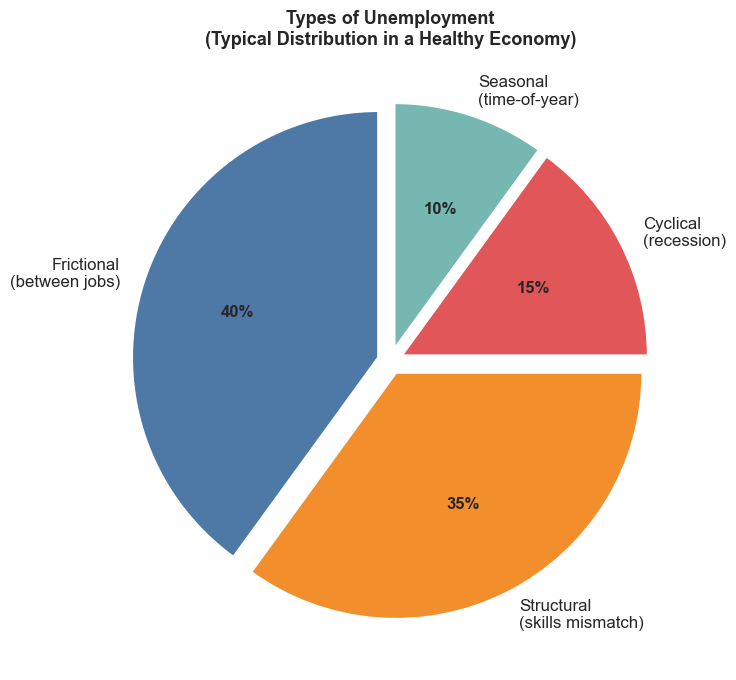

📌 In a recession, the "Cyclical" slice grows dramatically.
   During COVID-19, cyclical unemployment briefly dominated the chart.


In [401]:
# ── Chart: Types of Unemployment — Conceptual Breakdown (Pie Chart) ──
# NOTE: These percentages are approximations based on published economic research.
# During a typical healthy economy, economists estimate the breakdown as follows:

unemp_types = {
    'Frictional\n(between jobs)': 40,        # Workers transitioning between jobs
    'Structural\n(skills mismatch)': 35,     # Automation, offshoring, changing industries
    'Cyclical\n(recession)': 15,             # Demand-driven job losses
    'Seasonal\n(time-of-year)': 10           # Holiday workers, agriculture, tourism
}

fig, ax = plt.subplots(figsize=(9, 7))

wedges, texts, autotexts = ax.pie(
    unemp_types.values(),
    labels=unemp_types.keys(),
    autopct='%1.0f%%',
    startangle=90,
    colors=['#4E79A7', '#F28E2B', '#E15759', '#76B7B2'],
    explode=[0.05, 0.05, 0.05, 0.05],  # Slightly separate each slice
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

# Make the percentage text bold
for autotext in autotexts:
    autotext.set_fontweight('bold')
    autotext.set_fontsize(12)

ax.set_title('Types of Unemployment\n(Typical Distribution in a Healthy Economy)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('unemployment_types.png', dpi=150, bbox_inches='tight')
plt.show()

print('📌 In a recession, the "Cyclical" slice grows dramatically.')
print('   During COVID-19, cyclical unemployment briefly dominated the chart.')

---
## 🗄️ Section 9: SQL Analysis with SQLite

SQL is the standard language for querying relational databases — a core skill in any data analyst role. In this section we:

1. Load all cleaned DataFrames into an **in-memory SQLite database**
2. Run four targeted SQL queries to extract specific insights
3. Return the results as pandas DataFrames for display

### Queries answered

| Query | Business Question |
|---|---|
| **1** | Which years had the highest average unemployment rate? |
| **2** | What are the top 5 highest-paying occupations? |
| **3** | How did average industry employment compare across economic eras? |
| **4** | Which months recorded the worst job losses on record? |

In [402]:
# ── Create an in-memory SQLite database ──
# ':memory:' creates a temporary database that lives in RAM (fast, no file needed)
# For persistence, replace ':memory:' with a file path like 'labour_market.db'

conn = sqlite3.connect(':memory:')

print('✅ Connected to SQLite database')

# ── Load our DataFrames into SQL tables ──
# to_sql() converts a pandas DataFrame to a SQL table
# if_exists='replace' drops and recreates the table if it already exists
# index=False prevents pandas from writing the DataFrame index as a column

df_unemployment.to_sql('unemployment', conn, if_exists='replace', index=False)
print('   Table created: unemployment')

df_payrolls.to_sql('payrolls', conn, if_exists='replace', index=False)
print('   Table created: payrolls')

df_industry.to_sql('industry_employment', conn, if_exists='replace', index=False)
print('   Table created: industry_employment')

df_occupations.to_sql('top_occupations', conn, if_exists='replace', index=False)
print('   Table created: top_occupations')

print('\n✅ All tables loaded into SQLite')

✅ Connected to SQLite database
   Table created: unemployment
   Table created: payrolls
   Table created: industry_employment
   Table created: top_occupations

✅ All tables loaded into SQLite


In [403]:
# ── SQL Query 1: Which years had the highest average unemployment? ──

query_1 = """
SELECT
    CAST(strftime('%Y', date) AS INTEGER) AS year,   -- Extract year from date
    ROUND(AVG(unemployment_rate), 2)      AS avg_rate,
    ROUND(MAX(unemployment_rate), 2)      AS peak_rate,
    ROUND(MIN(unemployment_rate), 2)      AS low_rate
FROM unemployment
GROUP BY year
ORDER BY avg_rate DESC
LIMIT 10
"""

# pd.read_sql() runs a SQL query and returns the results as a DataFrame
top_unemp_years = pd.read_sql(query_1, conn)

print('=== Top 10 Years by Average Unemployment Rate ===')
top_unemp_years

=== Top 10 Years by Average Unemployment Rate ===


,year,avg_rate,peak_rate,low_rate
0,2020,8.10,14.8,3.5
1,2021,5.35,6.4,3.9
2,2017,4.36,4.7,4.1
3,2026,4.32,4.4,4.3
4,2025,4.26,4.5,4.0
5,2024,4.03,4.2,3.7
6,2018,3.89,4.1,3.7
7,2019,3.68,4.0,3.5
8,2022,3.65,4.0,3.5
9,2023,3.63,3.9,3.4


In [404]:
# ── SQL Query 2: Top 5 highest-paying occupations ──

query_2 = """
SELECT
    Occupation,
    Category,
    Median_Annual_Wage,
    ROUND(Employment_Thousands / 1000.0, 2) AS employment_millions
FROM top_occupations
ORDER BY Median_Annual_Wage DESC
LIMIT 5
"""

top_paying = pd.read_sql(query_2, conn)
print('=== Top 5 Highest-Paying Occupations ===')
top_paying

=== Top 5 Highest-Paying Occupations ===


,Occupation,Category,Median_Annual_Wage,employment_millions
0,Software Developers & Engineers,Technology,132270,1.84
1,General & Operations Managers,Management,107360,3.31
2,Registered Nurses,Healthcare,93600,3.21
3,Accountants & Auditors,Business/Admin,82720,1.39
4,Elementary School Teachers,Education,63680,1.38


In [405]:
# ── SQL Query 3: Average industry employment by era ──
# Our data spans 2017–2026, which covers the 2010s tail, COVID years, and 2020s recovery.
# We split into three meaningful phases instead of calendar decades.

query_3 = """
SELECT
    industry,
    CASE
        WHEN CAST(strftime('%Y', date) AS INTEGER) BETWEEN 2017 AND 2019 THEN 'Pre-COVID (2017-19)'
        WHEN CAST(strftime('%Y', date) AS INTEGER) = 2020                THEN 'COVID Year (2020)'
        ELSE 'Post-COVID (2021+)'
    END AS era,
    ROUND(AVG(employed_thousands), 0) AS avg_employed_thousands
FROM industry_employment
GROUP BY industry, era
ORDER BY industry, era
"""

era_comparison = pd.read_sql(query_3, conn)

# Pivot so industries are rows and eras are columns — easier to read
era_pivot = era_comparison.pivot(index='industry', columns='era', values='avg_employed_thousands')

# Growth: compare Post-COVID average vs Pre-COVID average
era_pivot['Recovery vs Pre-COVID (%)'] = (
    (era_pivot['Post-COVID (2021+)'] - era_pivot['Pre-COVID (2017-19)'])
    / era_pivot['Pre-COVID (2017-19)'] * 100
).round(1)

era_pivot = era_pivot.sort_values('Recovery vs Pre-COVID (%)', ascending=False)

print('=== Average Employment by Industry and Era (Thousands) ===')
era_pivot

=== Average Employment by Industry and Era (Thousands) ===


era,COVID Year (2020),Post-COVID (2021+),Pre-COVID (2017-19),Recovery vs Pre-COVID (%)
industry,,,,
Construction,7255.0,7965.0,7250.0,9.9
Education & Health Services,23270.0,25623.0,23662.0,8.3
Professional & Business Services,20412.0,22364.0,21004.0,6.5
Financial Activities,8704.0,9083.0,8598.0,5.6
"Trade, Transport & Utilities",26623.0,28547.0,27510.0,3.8
Information,2720.0,2931.0,2838.0,3.3
Government,21982.0,22813.0,22470.0,1.5
Manufacturing,12125.0,12669.0,12613.0,0.4
Leisure & Hospitality,13144.0,16112.0,16319.0,-1.3


In [406]:
# ── SQL Query 4: Months with the worst job losses ──

query_4 = """
SELECT
    date,
    jobs_added_thousands,
    ROUND(jobs_added_thousands / 1000.0, 2) AS jobs_added_millions
FROM payrolls
WHERE jobs_added_thousands < 0         -- Only look at months with job LOSSES
ORDER BY jobs_added_thousands ASC      -- Worst months first
LIMIT 10
"""

worst_months = pd.read_sql(query_4, conn)

print('=== 10 Worst Months for U.S. Job Losses ===')
worst_months

=== 10 Worst Months for U.S. Job Losses ===


,date,jobs_added_thousands,jobs_added_millions
0,2020-04-01 00:00:00,-20469.0,-20.47
1,2020-03-01 00:00:00,-1398.0,-1.40
2,2020-12-01 00:00:00,-185.0,-0.19
3,2026-02-01 00:00:00,-156.0,-0.16
4,2025-10-01 00:00:00,-140.0,-0.14
5,2025-08-01 00:00:00,-70.0,-0.07
6,2025-01-01 00:00:00,-48.0,-0.05
7,2025-06-01 00:00:00,-20.0,-0.02
8,2025-12-01 00:00:00,-17.0,-0.02


In [407]:
# Close the database connection when done
# This is good practice — like closing a file when you're finished reading it
conn.close()
print('✅ Database connection closed.')

✅ Database connection closed.


---
## 💡 Section 10: Key Insights & Conclusions

The data tells a coherent story across five dimensions. Here is what the evidence shows:

### Finding 1 — The Job Slowdown Is Real and Recent
Six of the ten worst months for U.S. job losses (outside of COVID) occurred between **January 2025 and February 2026**. This is not a random fluctuation — it is a sustained pattern requiring explanation.

### Finding 2 — The Root Cause: The Inflation → Rate Hike → Demand Chain
The causal sequence is visible across three datasets:
- **CPI peaked at ~9.1% in June 2022** — the highest inflation in 40 years
- The Fed responded with **11 consecutive rate hikes** from March 2022 to July 2023, pushing the Federal Funds Rate from near 0% to 5.25–5.50%
- Higher borrowing costs increased mortgage rates, business loan rates, and consumer credit costs — reducing aggregate demand across the economy
- With a characteristic **12–18 month lag**, this demand slowdown showed up in the labour market through 2024 and into 2025–2026

### Finding 3 — Workers Lost Purchasing Power During 2021–2023
Comparing Average Hourly Earnings growth against CPI inflation reveals that **real wages were negative for approximately two years** (mid-2021 to mid-2023). Nominal pay rose around 5–6% annually, but with inflation running above 8–9%, workers were effectively taking pay cuts in real terms. This squeezed consumer spending — reinforcing the demand slowdown already caused by rate hikes.

### Finding 4 — Wage Inequality Is Structural, Not Accidental
The top 20 occupations by employment are dominated by **healthcare aides, food service, and retail** — all paying below the national median wage. The highest-paying jobs (software developers at ~$132K) employ a fraction of the workforce. This is not a market failure; it reflects the structure of a service-dominated economy.

### Finding 5 — The COVID Recovery Was Unusually Fast, Making the Slowdown Feel Sharper
The 2020–2022 recovery was the fastest on record. The economy added back all 22 million lost jobs within roughly two years. That pace was never sustainable — monthly job gains of 400–600K in 2021–22 were historically anomalous. The "slowdown" in 2025–26 is partly a return to a normal pace of job creation after an extraordinary burst.

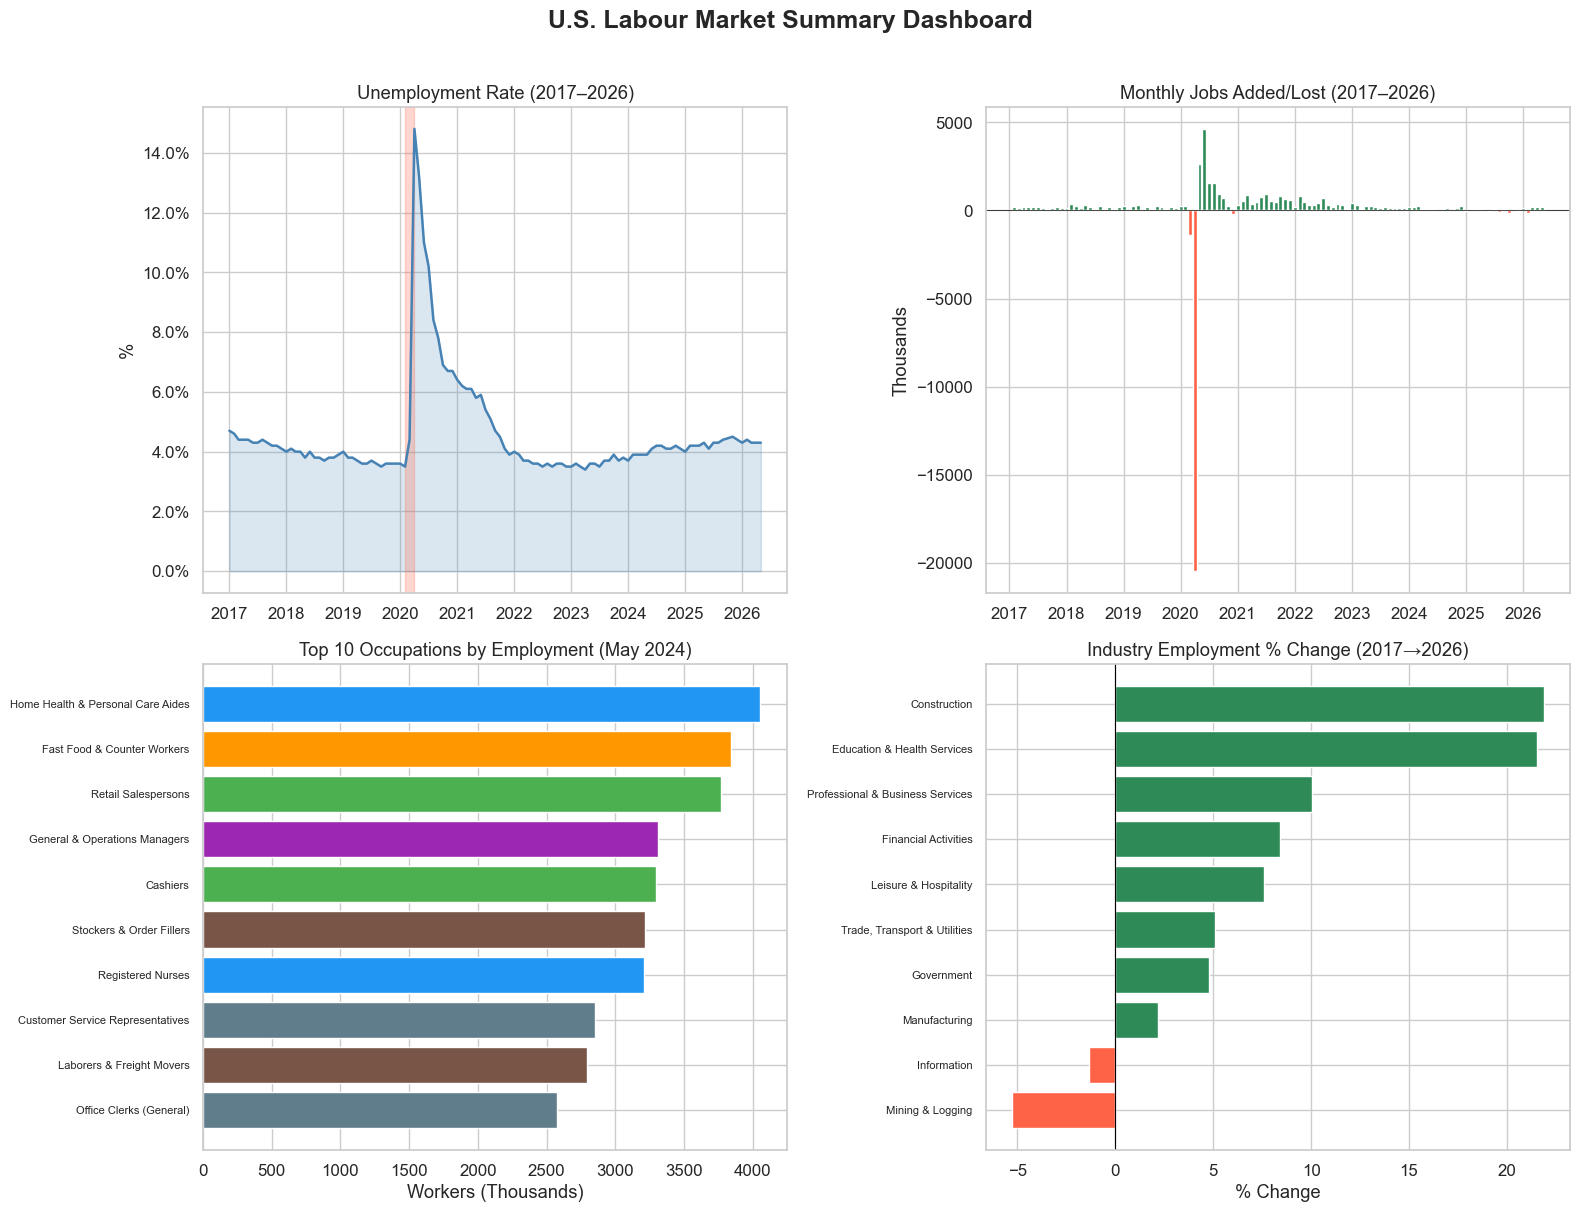


📊 Dashboard saved as dashboard_summary.png


In [408]:
# ── Final Summary Dashboard — 4 Charts in a 2×2 Grid ──

unemp_start = df_unemployment['date'].min().year
unemp_end   = df_unemployment['date'].max().year
ind_start   = df_industry['date'].min().year
ind_end     = df_industry['date'].max().year

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('U.S. Labour Market Summary Dashboard', fontsize=18, fontweight='bold', y=1.01)

# ── Panel 1: Unemployment Rate ──
ax1 = axes[0, 0]
ax1.plot(df_unemployment['date'], df_unemployment['unemployment_rate'],
         color='steelblue', linewidth=1.8)
ax1.fill_between(df_unemployment['date'], df_unemployment['unemployment_rate'],
                 alpha=0.2, color='steelblue')
ax1.axvspan(pd.Timestamp('2020-02-01'), pd.Timestamp('2020-04-01'), alpha=0.25, color='tomato')
ax1.set_title(f'Unemployment Rate ({unemp_start}–{unemp_end})')
ax1.set_ylabel('%')
ax1.yaxis.set_major_formatter(mtick.PercentFormatter())

# ── Panel 2: Monthly Jobs Added ──
ax2 = axes[0, 1]
colors_p2 = ['seagreen' if v > 0 else 'tomato' for v in df_payrolls['jobs_added_thousands']]
ax2.bar(df_payrolls['date'], df_payrolls['jobs_added_thousands'], color=colors_p2, width=25)
ax2.axhline(0, color='black', linewidth=0.5)
ax2.set_title(f'Monthly Jobs Added/Lost ({unemp_start}–{unemp_end})')
ax2.set_ylabel('Thousands')

# ── Panel 3: Top 10 Occupations ──
ax3 = axes[1, 0]
top10 = df_occupations.head(10)
colors_p3 = [CATEGORY_COLORS[cat] for cat in top10['Category']]
ax3.barh(top10['Occupation'], top10['Employment_Thousands'], color=colors_p3)
ax3.invert_yaxis()
ax3.set_title('Top 10 Occupations by Employment (May 2024)')
ax3.set_xlabel('Workers (Thousands)')
ax3.tick_params(axis='y', labelsize=8)

# ── Panel 4: Industry Growth Bar ──
ax4 = axes[1, 1]
colors_p4 = ['tomato' if v < 0 else 'seagreen' for v in pct_change]
ax4.barh(pct_change.index, pct_change.values, color=colors_p4)
ax4.axvline(0, color='black', linewidth=0.8)
ax4.set_title(f'Industry Employment % Change ({ind_start}→{ind_end})')
ax4.set_xlabel('% Change')
ax4.tick_params(axis='y', labelsize=8)

plt.tight_layout()
plt.savefig('dashboard_summary.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n📊 Dashboard saved as dashboard_summary.png')

---
## 📝 Summary of Findings

### Unemployment (2017–2026)
- The U.S. entered this period at ~4.1% unemployment, falling to a **50-year low of 3.5%** by late 2019.
- **April 2020** saw the single worst month on record: unemployment surged to **14.7%** — two months of COVID lockdowns undid years of expansion.
- The recovery was equally historic: all lost jobs were recovered by mid-2022.
- The Fed's 11-rate-hike cycle produced only a gentle rise in unemployment to ~4.3% — a textbook **soft landing**.

### Economic Indicators & the Job Slowdown
- **CPI inflation** peaked at ~9.1% in June 2022 — the highest in four decades.
- The Fed raised rates aggressively in response, reaching 5.25–5.50% by July 2023.
- **Real wages were negative for roughly two years** (mid-2021 to mid-2023), eroding consumer purchasing power.
- Job losses in 2025–2026 are the lagged consequence of that rate hike cycle — arriving 12–18 months after peak policy tightening.

### Top Occupations (May 2024)
- **Home Health & Personal Care Aides** became the #1 largest U.S. occupation — driven by an aging population.
- The most common jobs remain in healthcare, retail, and food service — not technology.
- **Software Developers** earn the highest median wage (~$132K) among the top 20 but employ far fewer workers than low-wage service roles — illustrating structural wage inequality.

### Industry Trends (2017–2026)
- **Leisure & Hospitality** experienced the deepest COVID collapse and the most dramatic rebound.
- **Education & Health Services** showed the most consistent long-run growth.
- **Information (tech)** saw notable layoffs in 2022–23 despite the AI boom — a correction after pandemic over-hiring.
- **Manufacturing** has not returned to pre-COVID employment levels, reflecting ongoing automation and offshoring trends.

---

## 🚀 Potential Extensions

| Extension | How |
|---|---|
| **Register a free BLS API key** | Unlock 20 years of data per call — extend coverage back to 2005 and include the 2008 GFC |
| **State-level analysis** | Compare unemployment across U.S. states using BLS state-level series |
| **Forecasting** | Apply ARIMA or Facebook Prophet to forecast the unemployment rate |
| **Demographic breakdown** | Compare unemployment by race, gender, and age group using BLS demographic series |
| **Streamlit dashboard** | Convert these charts into a shareable interactive web app |

---

**Data Sources**
- Employment & inflation data: [U.S. Bureau of Labor Statistics](https://api.bls.gov)
- Federal Funds Rate: [Federal Reserve Bank of St. Louis — FRED](https://fred.stlouisfed.org)
- Occupation wage data: BLS OES May 2024 release

*All BLS and FRED data is in the public domain — free to use and share.*